# Data-Driven Discovery of X-ray Transients with Representation Learning
# Demonstration Notebook

Steven Dillmann, Contact: [stevendi@stanford.edu](stevendi@stanford.edu)

1st September 2024

### Imports and Set-Up

In [1]:
# Python Imports
import numpy as np
import pandas as pd
import os
import pickle
import json
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import widgets, HBox, Layout, VBox
import plotly.express as px
import plotly.graph_objs as go

# Custom Imports
from eventfile_representation import EtMap, EtdtCube
from feature_extraction import PcaExtractor, AutoencoderExtractor
from feature_projection import DimensionalityReduction, EmbeddingClustering
from lightcurve_plotter import LightCurve
from run_eventfile_representation import create_representation
from run_feature_extraction import extract_features
from run_dimensionality_reduction import reduce_dimensions
from run_embedding_clustering import cluster_embeddings

# Load the eventfiles and properties tables
eventfiles_path = '../datasets/eventfiles_table.csv'
properties_path = '../datasets/properties_table.csv'
properties_full_path = '../datasets/properties_full_table.csv'
bonafide_path = '../datasets/bonafide_transients.json'
df_eventfiles = pd.read_csv(eventfiles_path)
df_properties = pd.read_csv(properties_path)
df_properties_full = pd.read_csv(properties_full_path)
unique_ids = df_eventfiles['obsreg_id'].unique()
var_index_b = df_properties['var_index_b'].values
hard_hs = df_properties['hard_hs'].values


### 1. Event File Representation

In [2]:
# Pick an example ID
id_example = '23022_122'
id_widget = widgets.Text(value=id_example, placeholder='Enter ID manually', description='Manual ID:', disabled=False, style={'description_width': 'initial'})
display(id_widget)

Text(value='23022_122', description='Manual ID:', placeholder='Enter ID manually', style=TextStyle(description…

,name,ra,dec,err_ellipse_r0,err_ellipse_r1,err_ellipse_ang,significance,likelihood_class,conf_flag,sat_src_flag,streak_src_flag,flux_aper_b,flux_aper_lolim_b,flux_aper_hilim_b,flux_aper_w,flux_aper_lolim_w,flux_aper_hilim_w,flux_aper_avg_b,flux_aper_avg_lolim_b,flux_aper_avg_hilim_b,flux_aper_avg_w,flux_aper_avg_lolim_w,flux_aper_avg_hilim_w,obsid,obi,gti_obs,gti_end,region_id,theta,phi,flux_significance_b,flux_significance_w,likelihood_b,likelihood_w,conf_code,extent_code,sat_src_flag.1,streak_src_flag.1,var_code,major_axis_b,minor_axis_b,pos_angle_b,major_axis_w,minor_axis_w,pos_angle_w,cnts_aper_b,cnts_aperbkg_b,cnts_aper_w,src_cnts_aper_b,src_cnts_aper_w,src_rate_aper_b,src_rate_aper_w,flux_aper_b.1,flux_aper_lolim_b.1,flux_aper_hilim_b.1,flux_aper_w.1,flux_aper_lolim_w.1,flux_aper_hilim_w.1,hard_hm,hard_hm_lolim,hard_hm_hilim,hard_ms,hard_ms_lolim,hard_ms_hilim,hard_hs,hard_hs_lolim,hard_hs_hilim,var_prob_b,var_prob_h,var_prob_m,var_prob_s,var_index_b,var_index_w,livetime,detector,obsreg_id
20192,2CXO J051117.2-672556,77.822016,-67.432396,1.859151,1.339932,5.1285,11.642147,TRUE,True,False,False,0.0,0.0,9.789457e-16,NaN,NaN,NaN,3.314104e-16,0.0,9.942313e-16,NaN,NaN,NaN,23022,0,2020-05-15T12:05:31,2020-05-15T19:03:13,122,11.745694,354.883179,11.642147,NaN,327.572054,NaN,15,0,False,False,28,4.864212,4.864212,0.0,NaN,NaN,NaN,219,716,NaN,192.076596,NaN,0.007765,NaN,1.915948e-13,1.651249e-13,2.180647e-13,NaN,NaN,NaN,0.7208,0.662711,0.777639,-0.276077,-0.491568,0.053092,0.607121,0.452842,0.785134,1.0,1.0,1.0,NaN,10.0,NaN,24734.882334,ACIS-8,23022_122


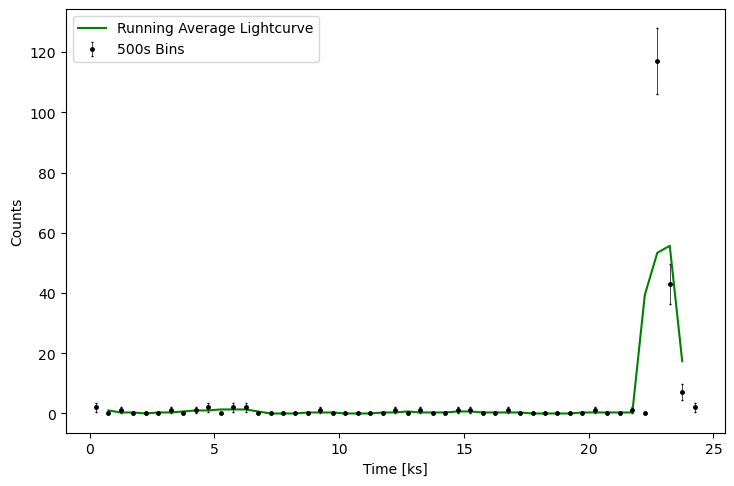

/Users/steven/Desktop/harvard-paper/ml-xraytransients-mnras/src/eventfile_representation.py:162: RuntimeWarning: divide by zero encountered in log
  ax.scatter(dt_mesh, t_mesh, E_mesh, s=5*np.log(Etdt_mesh*1000), alpha=0.9, edgecolors='k',


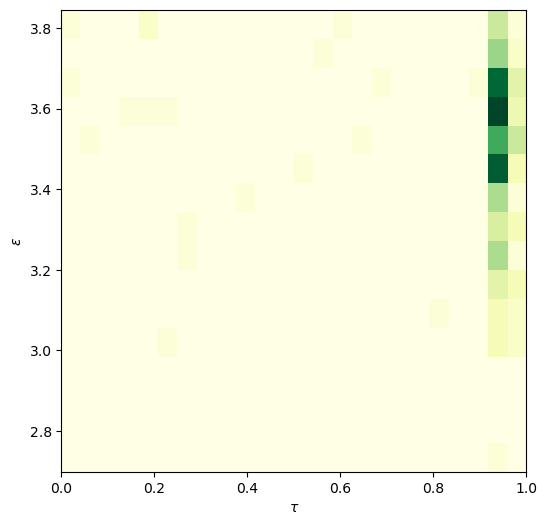

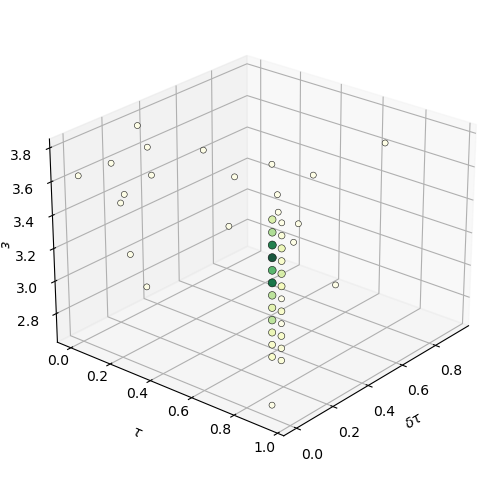

In [3]:
# === Eventfile Representation Example ========================================

# Example event file
example_id = id_widget.value
df_example = df_eventfiles[df_eventfiles['obsreg_id'] == example_id]
time_example = df_example['time'].values
energy_example = df_example['energy'].values

# Print information
example_properties = df_properties_full[df_properties_full['obsreg_id'] == example_id]
display(example_properties)

# Example Light Curve
lc = LightCurve()
binned_lc = lc.bin(df_example, bin_size_sec=500)
lc.visualise(color='k', ecolor='k', rcolor='green', lw=1.5, lwe=0.5, capsize=1, markersize=5)

# Example E-t Map
et = EtMap()
et.create_representation(time_example, energy_example)
et.visualize(cmap='YlGn', figsize=(6,6))

# Example E-t-dt Cube
etdt = EtdtCube()
etdt.create_representation(time_example, energy_example)
etdt.visualize(cmap='YlGn', figsize=(6,6))

In [4]:
# === Event File Representation on the entire dataset =========================

# Create the E-t Maps and E-t-dt Cubes (normalized)
print('Creating the E-t Maps (normalized)...')
create_representation(eventfiles_path, representation_type='et', normalize=True)
print('Creating the E-t-dt Cubes (normalized)...')
create_representation(eventfiles_path, representation_type='etdt', normalize=True)

# Create the E-t Maps and E-t-dt Cubes (normalized)
print('Creating the E-t Maps (not normalized)...')
create_representation(eventfiles_path, representation_type='et', normalize=False)
print('Creating the E-t-dt Cubes (not normalized)...')
create_representation(eventfiles_path, representation_type='etdt', normalize=False)

Creating the E-t Maps (normalized)...
Representations already exist at ../output/representations/et_16-24_normTrue_representations.pkl.
Creating the E-t-dt Cubes (normalized)...
Representations already exist at ../output/representations/etdt_16-24-16_normTrue_representations.pkl.
Creating the E-t Maps (not normalized)...
Representations already exist at ../output/representations/et_16-24_normFalse_representations.pkl.
Creating the E-t-dt Cubes (not normalized)...
Representations already exist at ../output/representations/etdt_16-24-16_normFalse_representations.pkl.


### 2. Feature Extraction

In [5]:
# === Feature Extraction Type Selection =======================================

# Pick the representations
files = os.listdir('../output/representations')
representation_widget = widgets.Dropdown(options=files,value=files[0], description='Representation:', disabled=False,  style={'description_width': 'initial'})

# Pick the feature extractor
encoders = os.listdir('../encoders')
encoders = ["../encoders/" + encoder for encoder in encoders]
extractors = ["PCA"] + encoders
feature_extractor_widget = widgets.Dropdown(options=extractors, value="PCA", description="Extractor:", disabled=False, style={'description_width': 'initial'})

# Pick the number of PCA components
n_pca_widget = widgets.IntSlider(
    value=15, min=2, max=100, step=1, 
    description="PCs:", 
    disabled=False, continuous_update=False, 
    readout=True, readout_format='d',
    style={'description_width': 'initial'}
)

# Display the widgets
def update_pca_widget_visibility(change):
    if change['new'] == "PCA":
        n_pca_widget.layout.display = 'flex'
    else:
        n_pca_widget.layout.display = 'none'   

feature_extractor_widget.observe(update_pca_widget_visibility, names='value')
update_pca_widget_visibility({'new': feature_extractor_widget.value})
print('Select normalized representations if you use the Autoencoder method.')
print('Select not normalized representations if you use the PCA method.')
display(HBox([representation_widget, feature_extractor_widget, n_pca_widget]))

Select normalized representations if you use the Autoencoder method.
Select not normalized representations if you use the PCA method.


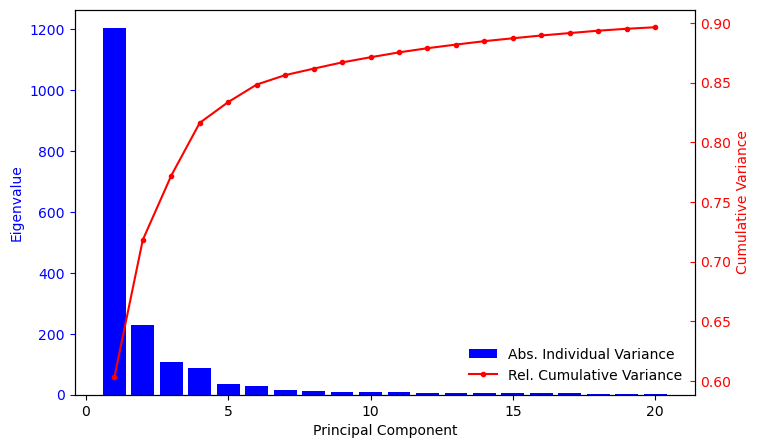

Extracting features using PCA (15 components)...
Extracted Features already exist at ../output/features/etdt_16-24-16_normFalse_PCA15_features.pkl.


In [6]:
# === PCA Extraction Example ================================================== 

# Open the representation
with open('../output/representations/' + representation_widget.value, 'rb') as f:
    representations = pickle.load(f)
    id_list = representations.keys()
    rep_vals = representations.values()
    histograms = np.array([np.array(h).flatten() for h in rep_vals])

# Set up the PCA extractor
n_pca_example = 20
pca_example = PcaExtractor(n_components=n_pca_example)

# Extract the features
pca_example.extract_features(histograms)

# Visualize the PCA components
pca_example.visualize()
    
# === Feature Extraction ====================================================== 

# Extract the features with the selected method
extract_features('../output/representations/' + representation_widget.value, feature_extractor_widget.value, n_pca_widget.value)

### 3. Dimensionality Reduction

In [7]:
# === Dimensionality Reduction Settings =======================================

# Pick the features
feature_files = os.listdir('../output/features')
feature_widget = widgets.Dropdown(options=feature_files, value=feature_files[0], description='Features:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='652px'))

# Pick the dimensionality reduction hyperparameters
int_text_layout = Layout(width='160px')
tsne_perp_widget = widgets.IntText(
    value=30, description="Perplexity:", 
    disabled=False, style={'description_width': 'initial'},
    layout=int_text_layout
)

tsne_lr_widget = widgets.IntText(
    value=100, description="Learning Rate:", 
    disabled=False, style={'description_width': 'initial'},
    layout=int_text_layout
)

tsne_iter_widget = widgets.IntText(
    value=2000, description="Iterations:", 
    disabled=False, style={'description_width': 'initial'},
    layout=int_text_layout
)

tsne_rs_widget = widgets.IntText(
    value=11, description="Random State:", 
    disabled=False, style={'description_width': 'initial'},
    layout=int_text_layout
)

# Container for t-SNE widgets
tsne_widgets_container = HBox([tsne_perp_widget, tsne_lr_widget, tsne_iter_widget, tsne_rs_widget])
display(VBox([feature_widget, tsne_widgets_container]))

In [8]:
# === Dimensionality Reduction ================================================

# Reduce the dimensionality of the features
reduce_dimensions('../output/features/' + feature_widget.value, perplexity=tsne_perp_widget.value, learning_rate=tsne_lr_widget.value, n_iter=tsne_iter_widget.value, random_state=tsne_rs_widget.value)

Performing Dimensionality Reduction...
Embedding already exists at ../output/embeddings/etdt_16-24-16_normTrue_AE24_2Dperp30lr100iter2000exag1initrandomrs11_embedding.csv.


### 4. Clustering

In [9]:
# === Embedding Clustering Settings ===========================================

# Pick the embedding
embedding_files = os.listdir('../output/embeddings')
embedding_files = [embedding for embedding in embedding_files if 'clusters' not in embedding]
embedding_widget = widgets.Dropdown(options=embedding_files, value=embedding_files[0], description='Embedding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='650px'))

# Pick the clustering hyperparameters
int_text_layout = Layout()
dbscan_eps_widget = widgets.FloatSlider(value=2.5, min=0.1, max=5.0, step=0.05, description="Epsilon:", disabled=False, continuous_update=False, readout=True, readout_format='.2f', style={'description_width': 'initial'})
dbscan_min_samples_widget = widgets.IntSlider(value=25, min=2, max=100, step=1, description="Min Samples:", disabled=False, continuous_update=False, readout=True, readout_format='d', style={'description_width': 'initial'})
dbscan_widget_container = HBox([dbscan_eps_widget, dbscan_min_samples_widget])
display(VBox([embedding_widget, dbscan_widget_container]))


In [10]:
# === Embedding Clustering ====================================================

# Cluster the embedding
cluster_embeddings('../output/embeddings/' + embedding_widget.value, eps=dbscan_eps_widget.value, min_samples=dbscan_min_samples_widget.value)


Performing Embedding Clustering...
Embedding Clustering already exists at ../output/embeddings/et_16-24_normTrue_AE12_2Dperp40lr100iter3000exag1initrandomrs12_clusters_eps2.5ms25.csv.


### 5. Visualization

In [11]:
# Pick the embedding
results_files1 = os.listdir('../output/embeddings')
results_files1 = [embedding for embedding in results_files1 if 'clusters' not in embedding]
results_widget1 = widgets.Dropdown(options=results_files1, value=results_files1[0], description='Embedding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='704px'))

# Pick the color-coding property
color_coding_options = df_properties.columns[2:]
color_coding_widget = widgets.Dropdown(options=color_coding_options, value='var_index_b', description='Color Coding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='350px'))

# Pick the bonafide transients
with open(bonafide_path, 'r') as f:
    bonafide_examples = json.load(f)
bonafide_options = list(bonafide_examples.keys())
bonafide_widget = widgets.SelectMultiple(options=bonafide_options, value=bonafide_options, description='Bonafide Transients:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='350px'))
display(HBox([results_widget1, color_coding_widget]))
display(HBox([bonafide_widget]))

Color coding the embedding by the var_index_b...


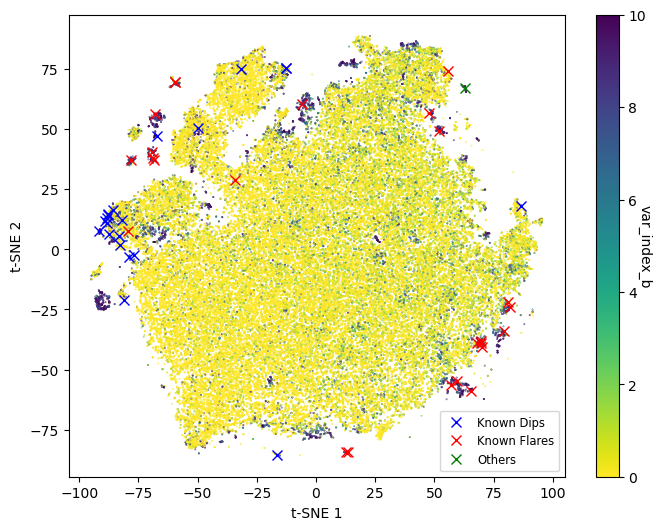

In [12]:
# === Embedding Visualization =================================================

# Load the embedding
df = pd.read_csv('../output/embeddings/' + results_widget1.value)
X_tsne = df[['tsne1', 'tsne2']].values

# Load the selected bonafide transients
with open(bonafide_path) as file:
    bonafide_examples = json.load(file)
bonafide_selected = [bonafide_examples[example] for example in bonafide_widget.value]
if len(bonafide_selected) != 0:
    df_list = []
    for enumerated, bonafide in enumerate(bonafide_selected):
        df_bonafide = df[df['obsreg_id'].isin(bonafide)].copy()
        df_bonafide['key'] = bonafide_widget.value[enumerated]
        df_list.append(df_bonafide)
    df_bon = pd.concat(df_list)
    df_bon.head()
    grouped_df = df_bon.groupby('key')
    grouped_dict = {key: group for key, group in grouped_df}
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    if len(grouped_dict) > len(colors):
        colors.extend(np.random.rand(len(grouped_dict) - len(colors), 3))

# Initialize the embedding object
dr = DimensionalityReduction()

# Color code the embedding
print(f'Color coding the embedding by the {str(color_coding_widget.value)}...')
axs = dr.visualize(X_tsne, colorcode = df_properties[color_coding_widget.value].values, cmap='viridis_r', label = str(color_coding_widget.value))
if len(bonafide_selected) != 0:
    for idx, (key, group) in enumerate(grouped_dict.items()):
        X_group = group[['tsne1', 'tsne2']].values
        axs.plot(X_group[:, 0], X_group[:, 1], color=colors[idx], label=key, marker='x', markersize=7, linestyle='None')
plt.legend(fontsize='small')
plt.show()


In [13]:
# Pick the clustered embedding
results_files2 = os.listdir('../output/embeddings')
results_files2 = [embedding for embedding in results_files2 if 'clusters' in embedding]
results_widget2 = widgets.Dropdown(options=results_files2, value=results_files2[0], description='Embedding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='704px'))

# Pick the bonafide transients
with open(bonafide_path, 'r') as f:
    bonafide_examples = json.load(f)
bonafide_options = list(bonafide_examples.keys())
bonafide_widget = widgets.SelectMultiple(options=bonafide_options, value=bonafide_options, description='Bonafide Transients:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='350px'))
display(HBox([results_widget2]))
display(HBox([bonafide_widget]))

Color coding the embedding by the clusters...


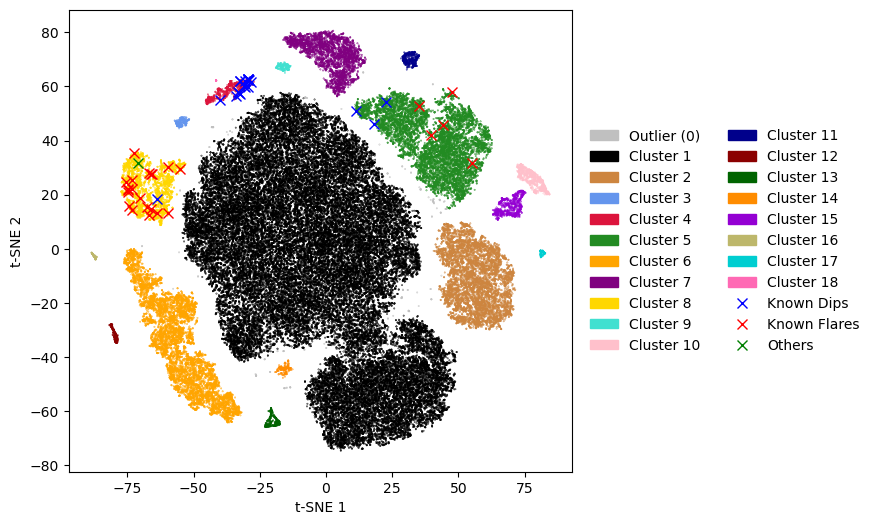

In [14]:
# === Embedding Clusters Visualization ========================================

# Load the embedding
df = pd.read_csv('../output/embeddings/' + results_widget2.value)
X_tsne = df[['tsne1', 'tsne2']].values
clusters = df['cluster'].values

# Load the selected bonafide transients
with open(bonafide_path) as file:
    bonafide_examples = json.load(file)
bonafide_selected = [bonafide_examples[example] for example in bonafide_widget.value]
if len(bonafide_selected) != 0:
    df_list = []
    for enumerated, bonafide in enumerate(bonafide_selected):
        df_bonafide = df[df['obsreg_id'].isin(bonafide)].copy()
        df_bonafide['key'] = bonafide_widget.value[enumerated]
        df_list.append(df_bonafide)
    df_bon = pd.concat(df_list)
    df_bon.head()
    grouped_df = df_bon.groupby('key')
    grouped_dict = {key: group for key, group in grouped_df}
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    if len(grouped_dict) > len(colors):
        colors.extend(np.random.rand(len(grouped_dict) - len(colors), 3))
        
# Color code the embedding by the cluster
ec = EmbeddingClustering()
print('Color coding the embedding by the clusters...')
axs, handles = ec.visualize(X_tsne, clusters, label='cluster')
if len(bonafide_selected) != 0:
    for idx, (key, group) in enumerate(grouped_dict.items()):
        X_group = group[['tsne1', 'tsne2']].values
        axs.plot(X_group[:, 0], X_group[:, 1], color=colors[idx], label=key, marker='x', markersize=7, linestyle='None')
    new_handles = [plt.Line2D([0], [0], color=colors[idx], marker='x', linestyle='None', markersize=7, label=key) for idx, key in enumerate(grouped_dict.keys())]
    handles.extend(new_handles)
    axs.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=2, frameon=False)
plt.show()


### 6. Selection

In [15]:
# Pick the clustered embedding
results_files3 = os.listdir('../output/embeddings')
results_widget3 = widgets.Dropdown(options=results_files3, value=results_files3[0], description='Embedding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='704px'))

# Pick the color-coding property
color_coding_options = df_properties.columns[2:]
color_coding_widget = widgets.Dropdown(options=color_coding_options, value='var_index_b', description='Color Coding:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='350px'))

# Pick the bonafide transients
with open(bonafide_path, 'r') as f:
    bonafide_examples = json.load(f)
bonafide_options = list(bonafide_examples.keys())
bonafide_widget = widgets.SelectMultiple(options=bonafide_options, value=bonafide_options, description='Bonafide Transients:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='350px'))

display(HBox([results_widget3, color_coding_widget]))
display(HBox([bonafide_widget]))

In [17]:
# === Interactive Embedding Visualization =====================================

# Load the embedding
df = pd.read_csv('../output/embeddings/' + results_widget3.value)
df_all = pd.merge(df, df_properties, on='obsreg_id')

# Load the selected bonafide transients
with open(bonafide_path) as file:
    bonafide_examples = json.load(file)
bonafide_selected = [bonafide_examples[example] for example in bonafide_widget.value]
if len(bonafide_selected) != 0:
    df_list = []
    for enumerated, bonafide in enumerate(bonafide_selected):
        df_bonafide = df[df['obsreg_id'].isin(bonafide)].copy()
        df_bonafide['key'] = bonafide_widget.value[enumerated]
        df_list.append(df_bonafide)
    df_bon = pd.concat(df_list)
    df_bon.head()
    grouped_df = df_bon.groupby('key')
    grouped_dict = {key: group for key, group in grouped_df}
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    if len(grouped_dict) > len(colors):
        colors.extend(np.random.rand(len(grouped_dict) - len(colors), 3))

# Initialize a global variable to store selected indices
selected_indices = []

# Create a Plotly FigureWidget
if 'cluster' in df_all.columns:
    hover_data = ['obsreg_id', 'var_index_b', 'hard_hs', 'cluster']
else:
    hover_data = ['obsreg_id', 'var_index_b', 'hard_hs']
color_by = color_coding_widget.value
fig = go.FigureWidget(px.scatter(df_all, x='tsne1', y='tsne2', hover_data=hover_data, color=color_by, color_continuous_scale='viridis_r'))
fig.update_layout(height=600, width=800)
fig.update_traces(marker=dict(size=2))
# Add bonafide transients
if len(bonafide_selected) != 0:
    for idx, (key, group) in enumerate(grouped_dict.items()):
        fig.add_trace(go.Scatter(x=group['tsne1'], y=group['tsne2'], mode='markers', marker=dict(color=colors[idx], size=10, symbol='circle-open', line=dict(width=2)), name=key))
fig.update_layout(legend=dict(x=1.15,  y=0.5, xanchor='left', yanchor='top'))

# Display the figure
display(fig)

# Capture selected points
def selection_fn(trace, points, selector):
    global selected_indices
    selected_indices = points.point_inds
fig.data[0].on_selection(selection_fn)

# Save selection?
save_name_widget = widgets.Text(value='lasso_selection', placeholder='Enter selection name', description='Save Name:', disabled=False, style={'description_width': 'initial'})
save_selection_widget = widgets.Checkbox(value=False, description='Save to File?', disabled=False, style={'description_width': 'initial'})
display(HBox([save_name_widget, save_selection_widget]))

/Users/steven/tensorflow-test/env/lib/python3.8/site-packages/jupyter_client/session.py:719: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



FigureWidget({
    'data': [{'customdata': array([['10037_123', 0.0, 0.78201124297314],
                                   ['10037_30', 0.0, 0.99937539038101],
                                   ['10037_40', 0.0, 0.34353529044347],
                                   ...,
                                   ['99_172', 6.0, -0.86445971267958],
                                   ['99_178', 0.0, -0.85196752029981],
                                   ['99_183', 0.0, -0.71455340412242]], dtype=object),
              'hovertemplate': ('tsne1=%{x}<br>tsne2=%{y}<br>ob' ... '{customdata[2]}<extra></extra>'),
              'legendgroup': '',
              'marker': {'color': array([0., 0., 0., ..., 6., 0., 0.]),
                         'coloraxis': 'coloraxis',
                         'size': 2,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'uid': '1328ba

In [26]:
# Check and save the selected points to a new dataframe
if selected_indices:
    selected_df = df_properties.iloc[selected_indices]
    print(f'{len(selected_indices)} points were selected.')
    if save_selection_widget.value:
        # create directory if it does not exist
        if not os.path.exists('../output/selections'):
            os.makedirs('../output/selections')
        selected_df.to_csv('../output/selections/' + save_name_widget.value + '.csv', index=False)
        print("Selection saved to 'output/selections/" + save_name_widget.value + ".csv'.")
else:
    print("No points were selected.")


86 points were selected.


### 7. Light Curves

In [27]:
# Pick a selection for light curve visualization
selection_files = os.listdir('../output/selections')
selection_files = ['Current Notebook Selection'] + selection_files
selection_widget = widgets.Dropdown(options=selection_files, value=selection_files[0], description='Selection:', disabled=False, style={'description_width': 'initial'}, layout=Layout(width='500px'))
bin_size_widget = widgets.IntSlider(value=500, min=10, max=2000, step=10, description="Bin Size (sec):", disabled=False, continuous_update=False, readout=True, readout_format='d', style={'description_width': 'initial'})
display(HBox([selection_widget, bin_size_widget]))

Plotting light curve for 10763_26...
Name: 2CXO J054618.8-000538, RA: 86.5787, DEC: -0.0939, Date: 2008-11-27T23:10:07
var_index_b: 2.0, hard_hs: -0.1524047470331


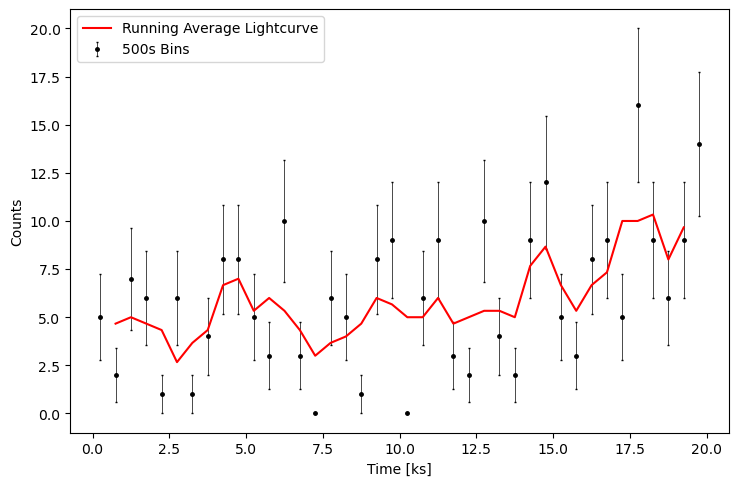

Plotting light curve for 11807_48...
Name: 2CXO J213720.8+572905, RA: 324.3369, DEC: 57.4849, Date: 2010-03-31T12:53:41
var_index_b: 10.0, hard_hs: -0.16489693941287


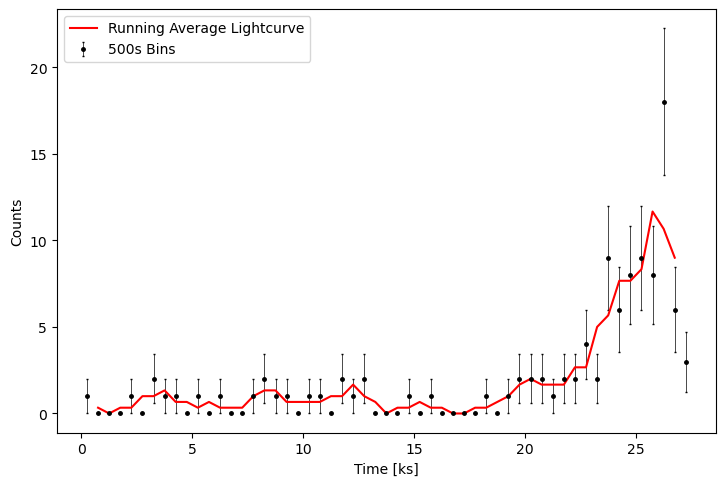

Plotting light curve for 11823_1901...
Name: 2CXO J161727.9-510821, RA: 244.3665, DEC: -51.1393, Date: 2010-06-01T05:44:23
var_index_b: 9.0, hard_hs: -0.25359150530918


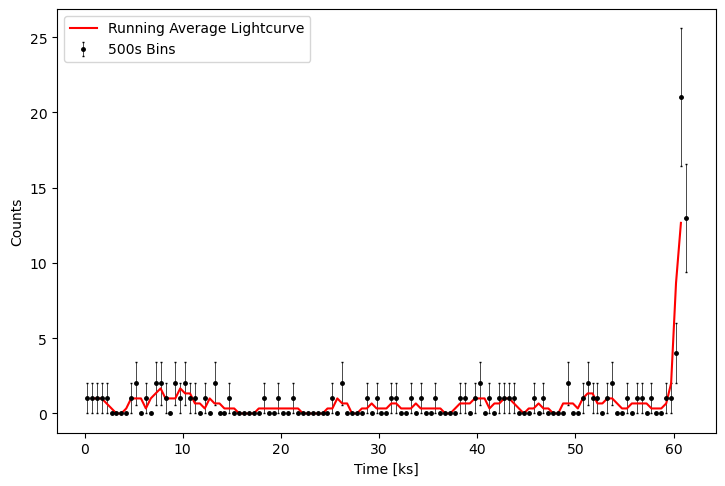

Plotting light curve for 12391_73...
Name: 2CXO J053555.0-065105, RA: 83.9795, DEC: -6.8513, Date: 2010-12-06T03:55:35
var_index_b: 9.0, hard_hs: 0.2948157401624


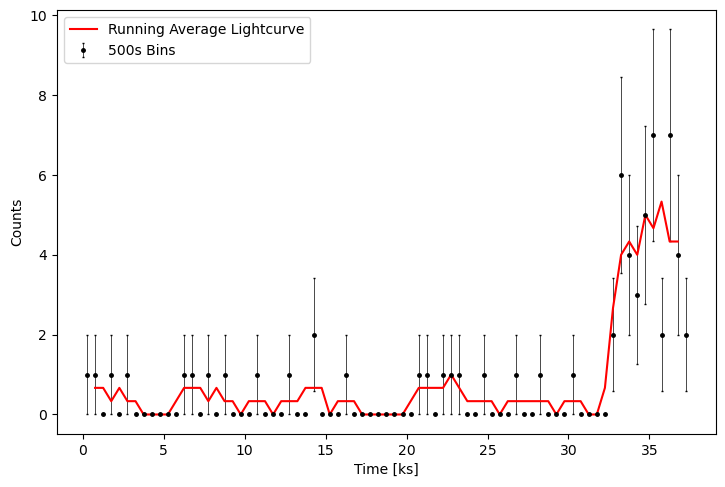

Plotting light curve for 12878_29...
Name: 2CXO J122607.4+214957, RA: 186.5313, DEC: 21.8326, Date: 2011-04-11T01:00:42
var_index_b: 8.0, hard_hs: -0.61336664584635


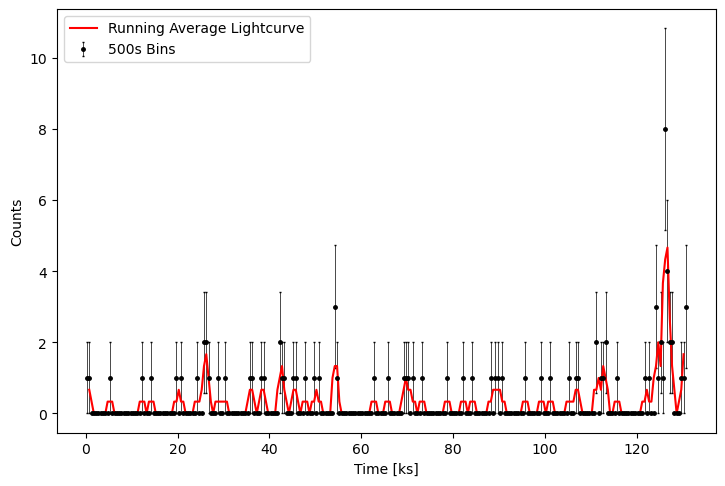

Plotting light curve for 13477_18...
Name: 2CXO J040717.6-480655, RA: 61.8236, DEC: -48.1154, Date: 2013-02-02T16:30:21
var_index_b: 9.0, hard_hs: -0.62211118051218


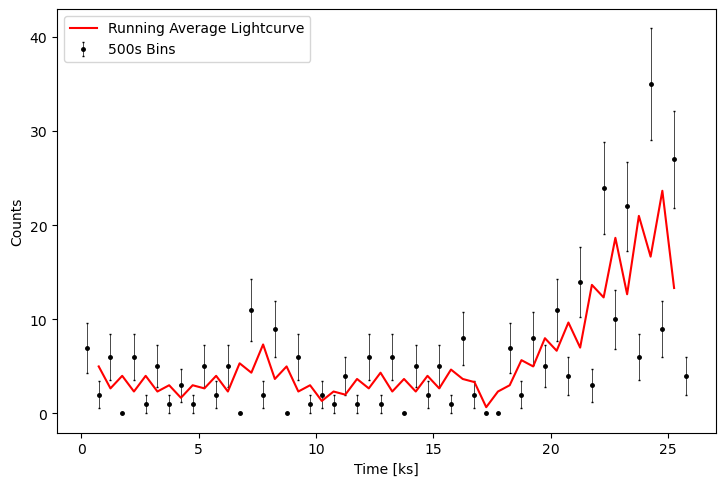

Plotting light curve for 13496_29...
Name: 2CXO J233415.5-454353, RA: 353.5649, DEC: -45.7314, Date: 2013-01-15T01:49:59
var_index_b: 8.0, hard_hs: -0.91442848219863


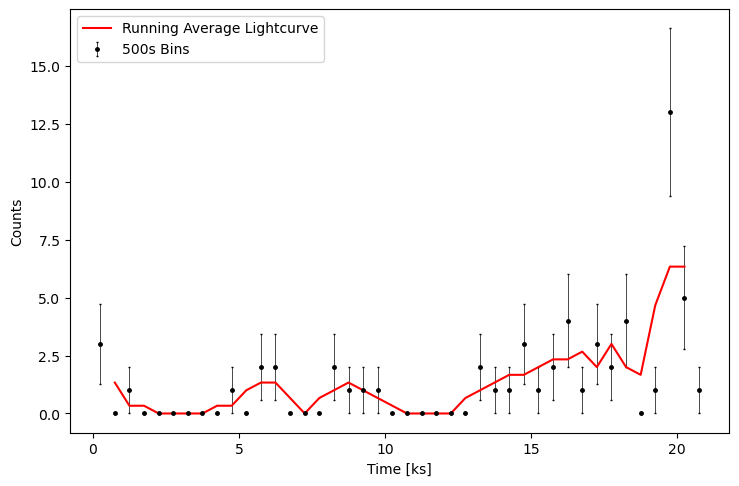

Plotting light curve for 13610_554...
Name: 2CXO J064101.8+093841, RA: 100.2576, DEC: 9.6447, Date: 2011-12-05T02:11:58
var_index_b: 8.0, hard_hs: -0.69581511555278


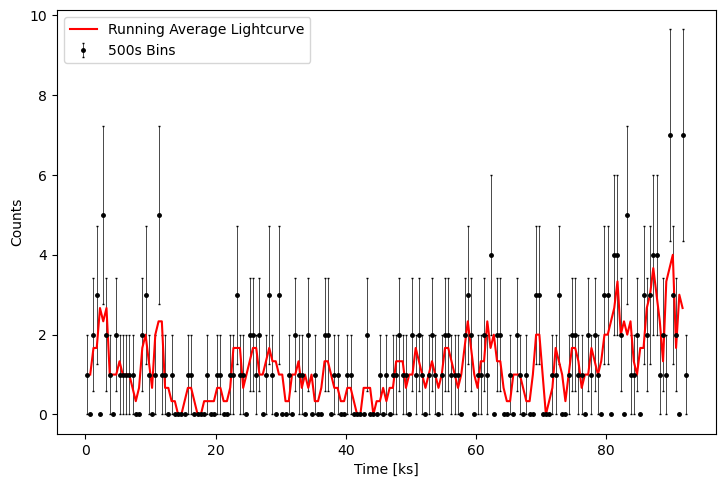

Plotting light curve for 13610_925...
Name: 2CXO J064129.4+093918, RA: 100.3727, DEC: 9.6550, Date: 2011-12-05T02:11:58
var_index_b: 9.0, hard_hs: -0.64959400374766


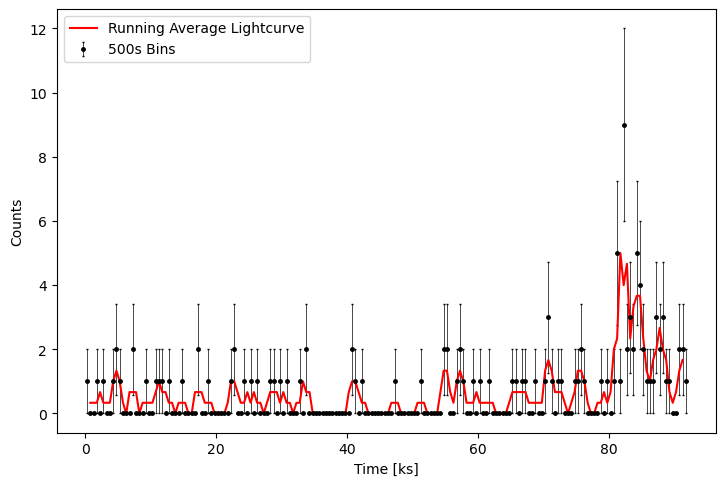

Plotting light curve for 13611_264...
Name: 2CXO J064118.3+093941, RA: 100.3266, DEC: 9.6615, Date: 2011-12-07T10:59:49
var_index_b: 8.0, hard_hs: -0.56964397251718


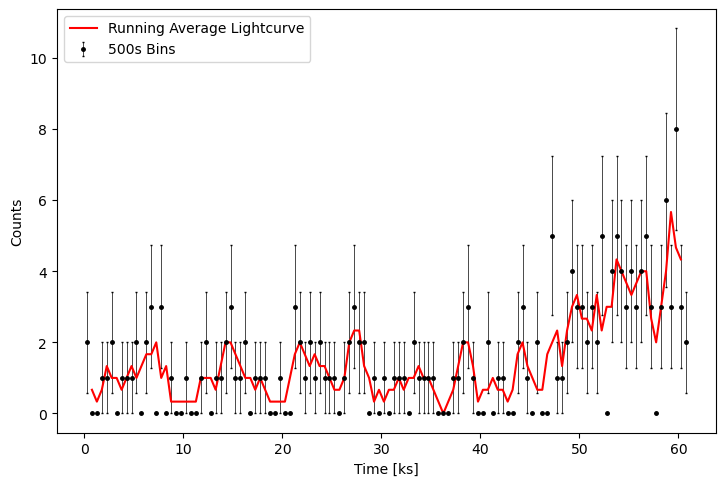

Plotting light curve for 13621_142...
Name: 2CXO J171241.2-382533, RA: 258.1717, DEC: -38.4260, Date: 2012-06-30T12:47:42
var_index_b: 9.0, hard_hs: 0.31480324797002


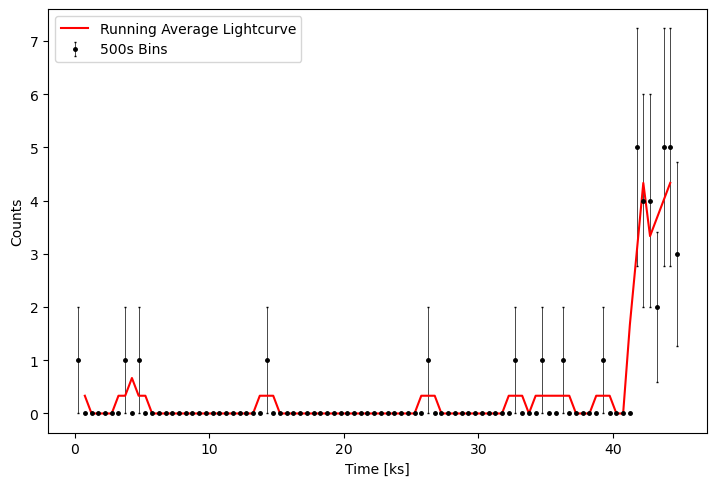

Plotting light curve for 14335_1064...
Name: 2CXO J053518.8-051445, RA: 83.8285, DEC: -5.2459, Date: 2012-10-04T08:39:21
var_index_b: 9.0, hard_hs: -0.20112429731418


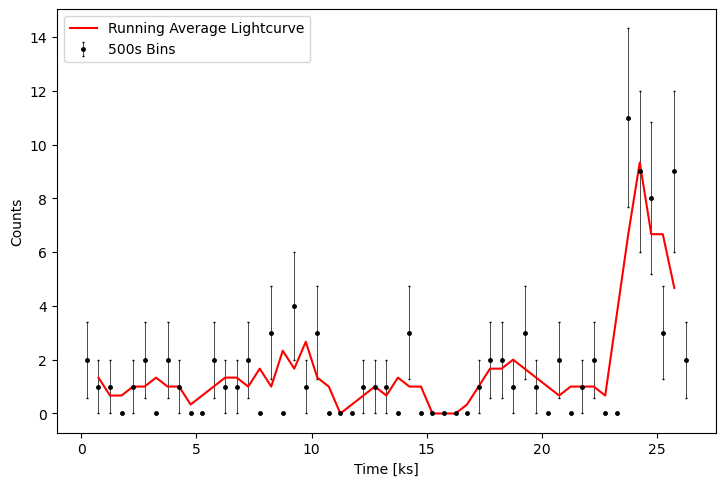

Plotting light curve for 14339_255...
Name: 2CXO J174750.4-244615, RA: 266.9602, DEC: -24.7711, Date: 2011-09-08T03:50:07
var_index_b: 10.0, hard_hs: 0.067457838850718


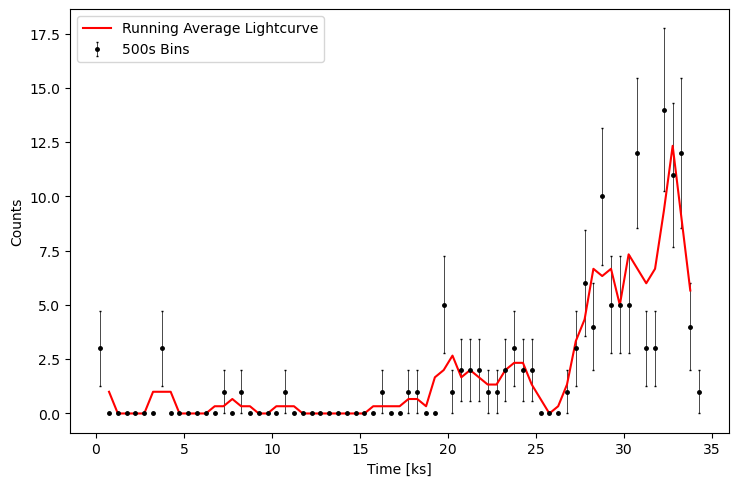

Plotting light curve for 14369_478...
Name: 2CXO J064103.4+093005, RA: 100.2642, DEC: 9.5014, Date: 2011-12-08T05:12:23
var_index_b: 7.0, hard_hs: -0.70455965021861


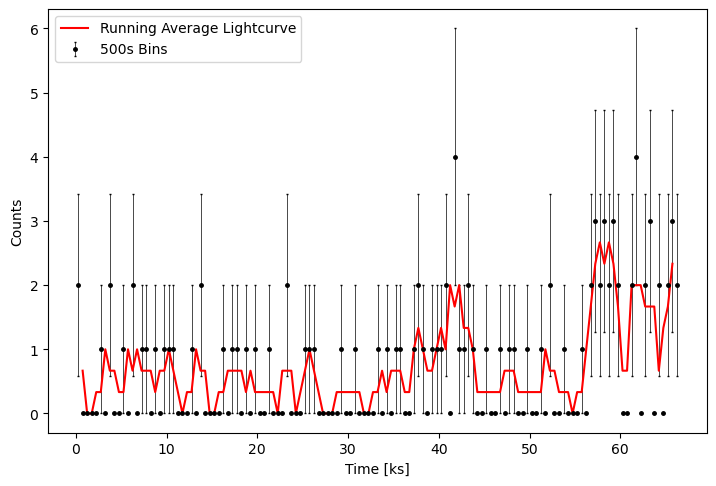

Plotting light curve for 14419_520...
Name: 2CXO J100459.9-073232, RA: 151.2500, DEC: -7.5423, Date: 2012-04-05T19:03:53
var_index_b: 8.0, hard_hs: -0.90443472829482


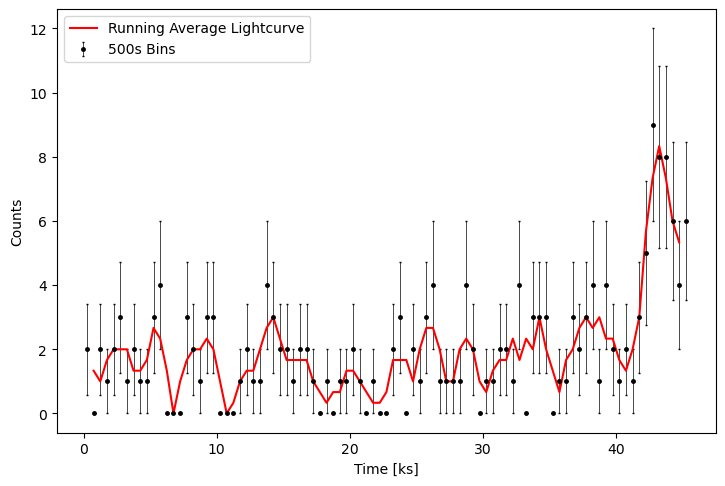

Plotting light curve for 14531_57...
Name: 2CXO J162052.4-503725, RA: 245.2186, DEC: -50.6237, Date: 2013-06-25T02:02:38
var_index_b: 9.0, hard_hs: -0.51093066833229


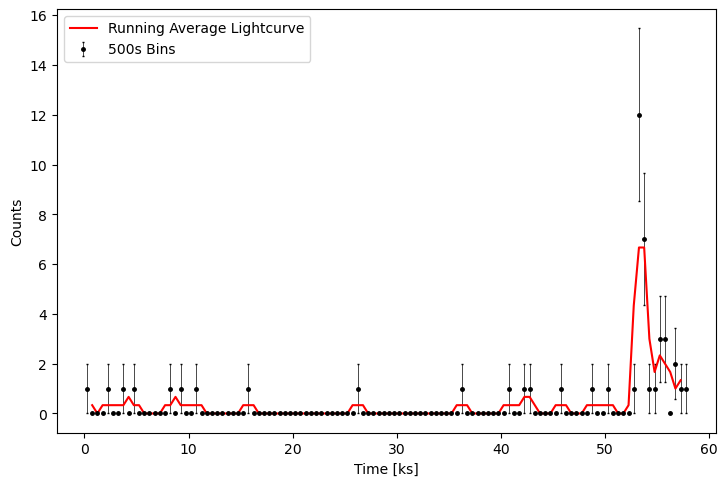

Plotting light curve for 14536_7...
Name: 2CXO J000223.9+672000, RA: 0.5997, DEC: 67.3335, Date: 2014-01-14T18:15:34
var_index_b: 9.0, hard_hs: 0.45221736414741


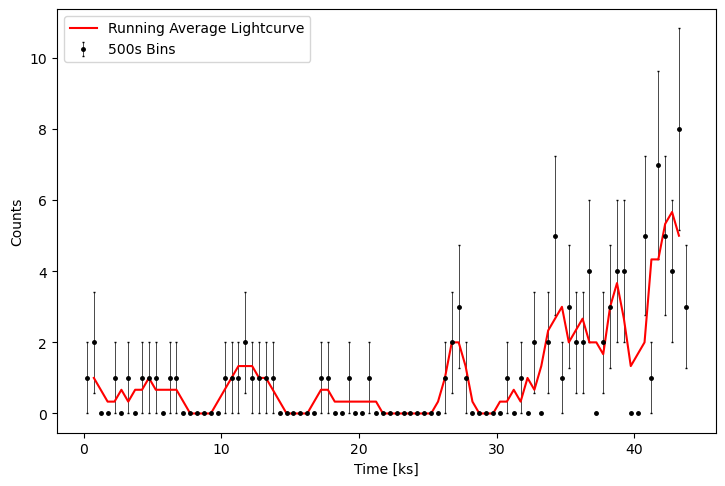

Plotting light curve for 14544_21...
Name: 2CXO J091508.9-500210, RA: 138.7874, DEC: -50.0362, Date: 2014-03-25T03:12:26
var_index_b: 9.0, hard_hs: -0.44846970643348


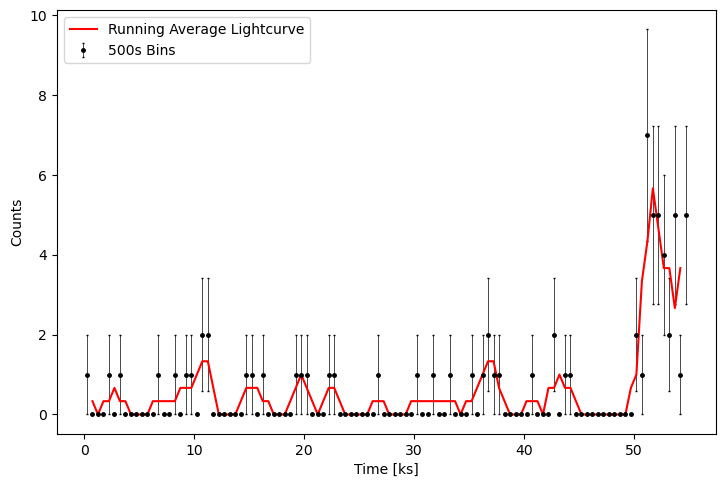

Plotting light curve for 14940_28...
Name: 2CXO J052043.2+303301, RA: 80.1801, DEC: 30.5504, Date: 2013-11-12T04:58:55
var_index_b: 8.0, hard_hs: -0.71705184259838


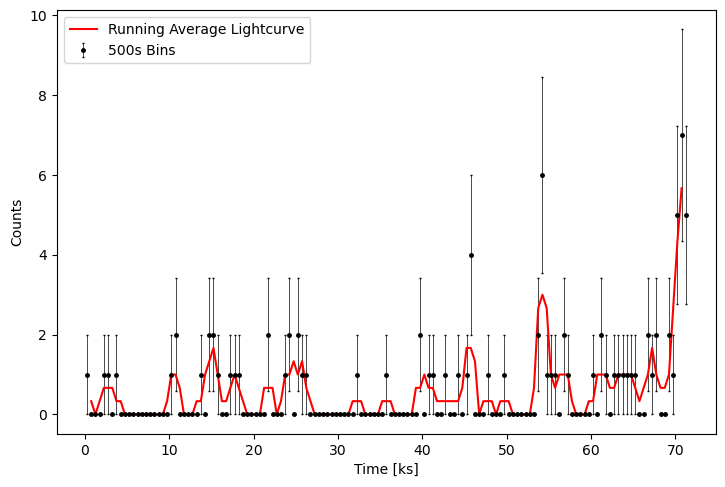

Plotting light curve for 14940_52...
Name: 2CXO J052017.9+303706, RA: 80.0749, DEC: 30.6186, Date: 2013-11-12T04:58:55
var_index_b: 10.0, hard_hs: -0.35477826358526


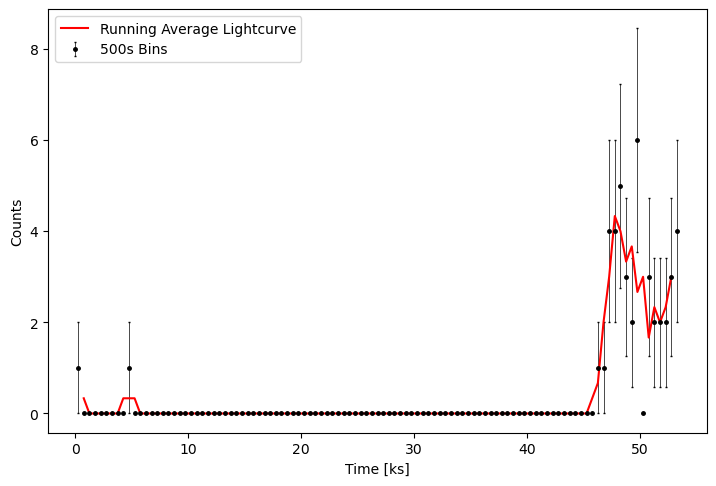

Plotting light curve for 15093_139...
Name: 2CXO J004448.4-203414, RA: 11.2020, DEC: -20.5707, Date: 2013-09-12T09:07:22
var_index_b: 8.0, hard_hs: -0.83822610868207


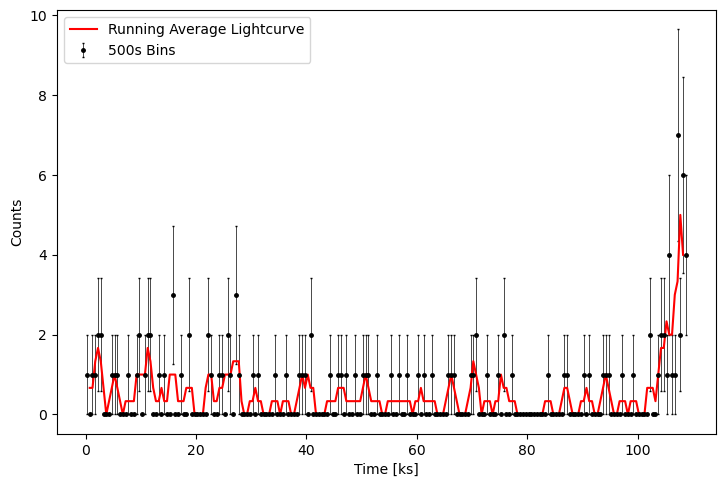

Plotting light curve for 15377_76...
Name: 2CXO J145804.8+472423, RA: 224.5201, DEC: 47.4067, Date: 2013-09-09T01:11:49
var_index_b: 2.0, hard_hs: -0.9631480324797


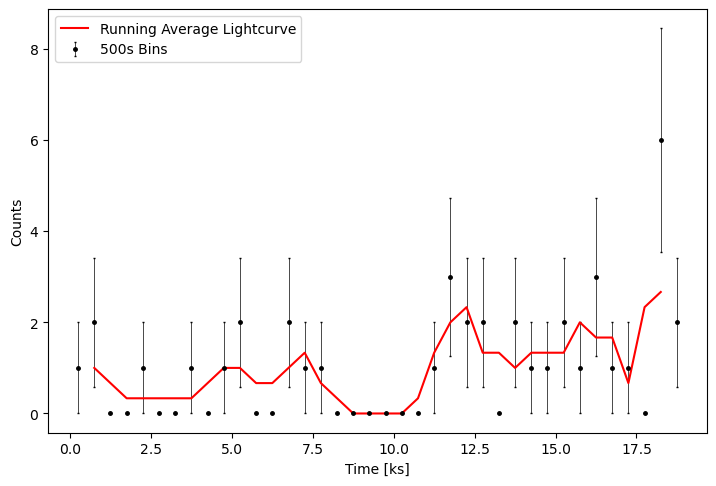

Plotting light curve for 15393_184...
Name: 2CXO J162030.2-505107, RA: 245.1259, DEC: -50.8522, Date: 2013-07-03T00:43:29
var_index_b: 10.0, hard_hs: -0.68457214241099


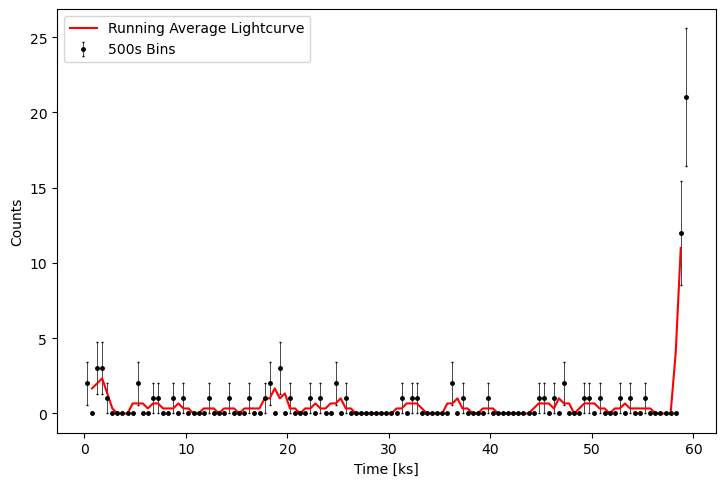

Plotting light curve for 15761_82...
Name: 2CXO J170050.6-301955, RA: 255.2109, DEC: -30.3320, Date: 2014-05-05T19:42:04
var_index_b: 4.0, hard_hs: -0.36352279825109


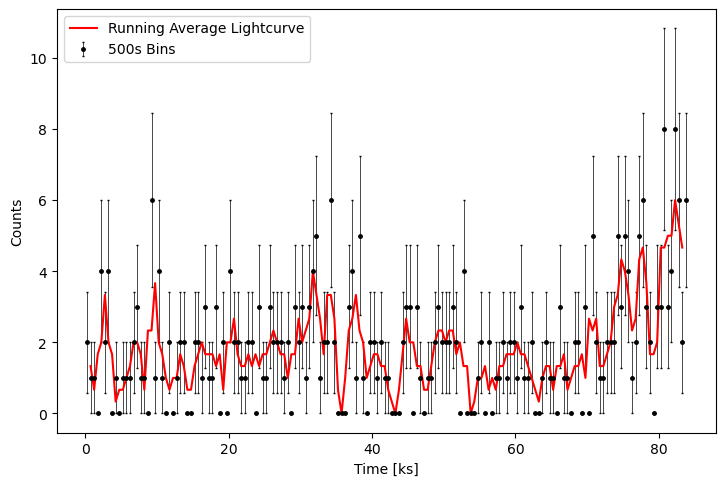

Plotting light curve for 1578_37...
Name: 2CXO J120703.7+430348, RA: 181.7656, DEC: 43.0634, Date: 2001-05-27T11:45:10
var_index_b: 0.0, hard_hs: -0.5159275452842


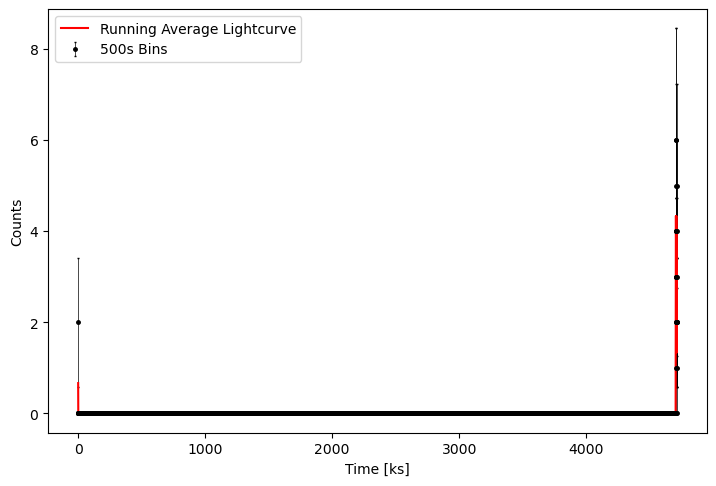

Plotting light curve for 16312_14...
Name: 2CXO J192702.9+210322, RA: 291.7621, DEC: 21.0562, Date: 2015-02-19T04:18:19
var_index_b: 8.0, hard_hs: -0.32229856339788


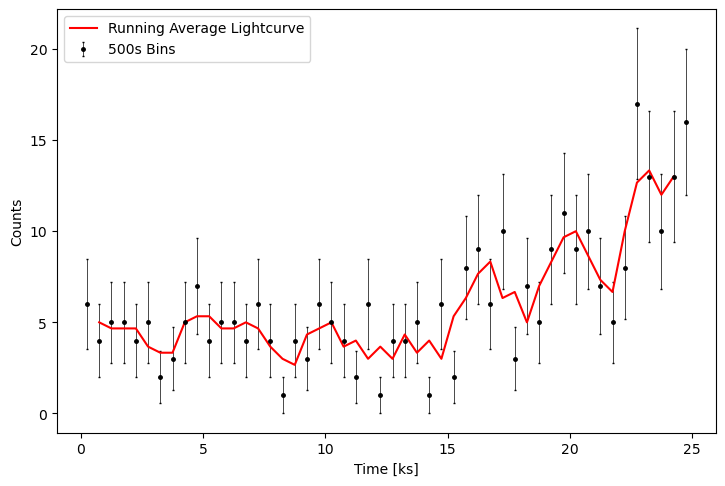

Plotting light curve for 16446_165...
Name: 2CXO J053935.5-690438, RA: 84.8982, DEC: -69.0773, Date: 2015-06-02T12:07:10
var_index_b: 10.0, hard_hs: -0.14366021236727


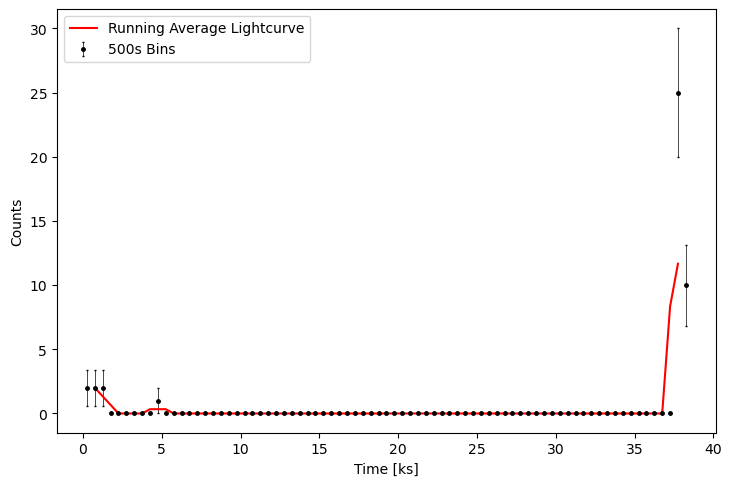

Plotting light curve for 16543_108...
Name: 2CXO J064457.6+001556, RA: 101.2401, DEC: 0.2658, Date: 2013-12-03T18:48:29
var_index_b: 9.0, hard_hs: 0.29231730168645


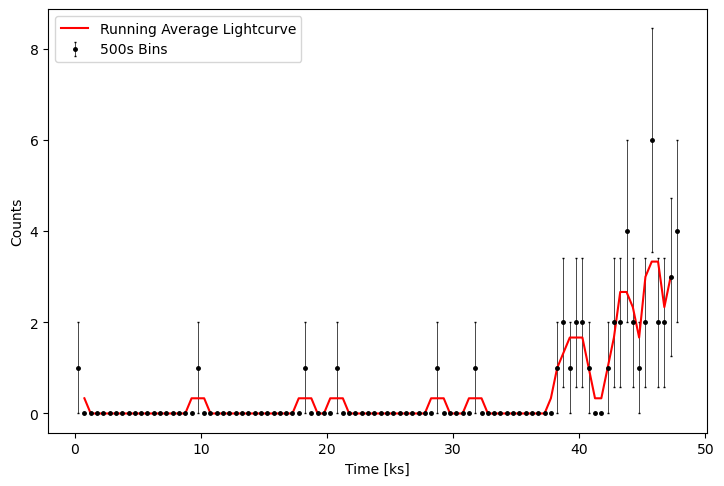

Plotting light curve for 16673_145...
Name: 2CXO J183834.4-065136, RA: 279.6434, DEC: -6.8603, Date: 2016-02-13T16:40:46
var_index_b: 8.0, hard_hs: -0.88069956277327


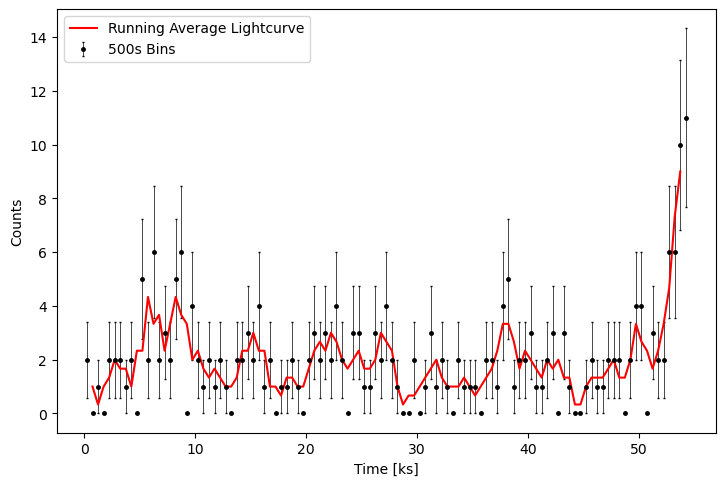

Plotting light curve for 16771_33...
Name: 2CXO J164114.8-463133, RA: 250.3119, DEC: -46.5259, Date: 2015-01-22T16:53:13
var_index_b: 9.0, hard_hs: -0.67707682698314


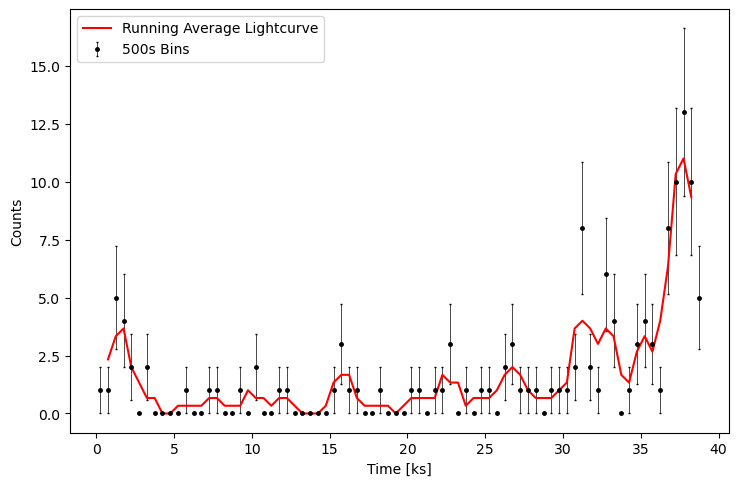

Plotting light curve for 17306_134...
Name: 2CXO J021830.1-045512, RA: 34.6255, DEC: -4.9202, Date: 2015-07-08T07:48:02
var_index_b: 0.0, hard_hs: -0.89943785134291


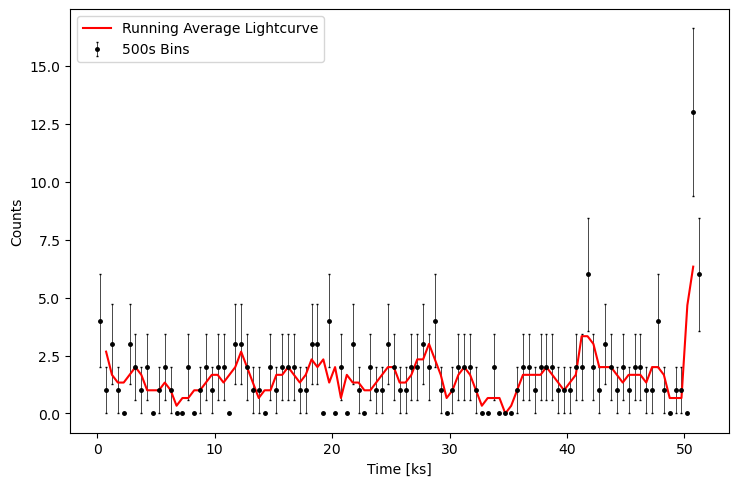

Plotting light curve for 1882_206...
Name: 2CXO J060725.9-062125, RA: 91.8582, DEC: -6.3572, Date: 2000-12-02T23:31:06
var_index_b: 5.0, hard_hs: 0.4472204871955


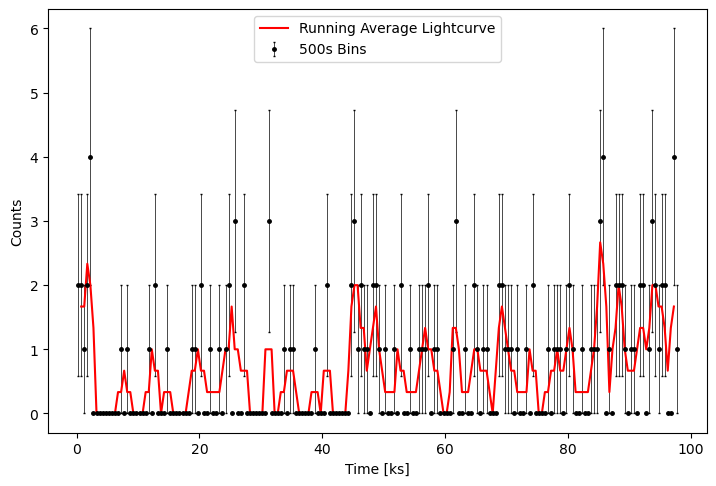

Plotting light curve for 1882_276...
Name: 2CXO J060755.9-061538, RA: 91.9830, DEC: -6.2608, Date: 2000-12-02T23:31:06
var_index_b: 9.0, hard_hs: -0.28981886321049


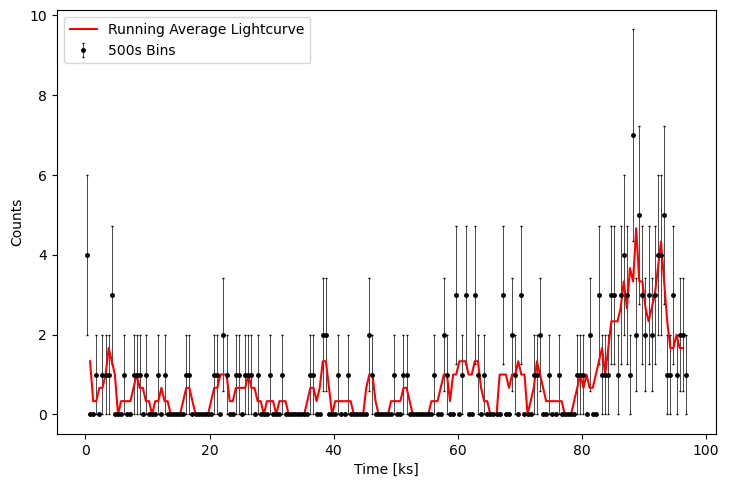

Plotting light curve for 1983_345...
Name: 2CXO J193047.7+185258, RA: 292.6991, DEC: 18.8828, Date: 2001-06-06T18:31:05
var_index_b: 9.0, hard_hs: -0.65708931917552


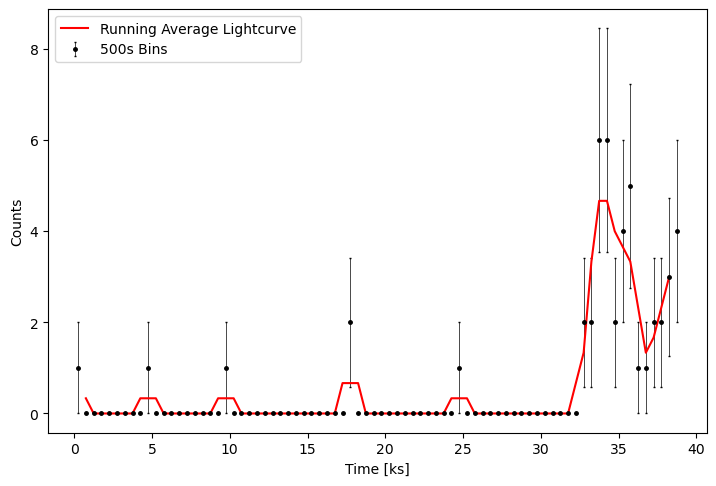

Plotting light curve for 20289_6...
Name: 2CXO J160928.5-320617, RA: 242.3689, DEC: -32.1049, Date: 2018-06-20T02:05:27
var_index_b: 7.0, hard_hs: -0.8682073703935


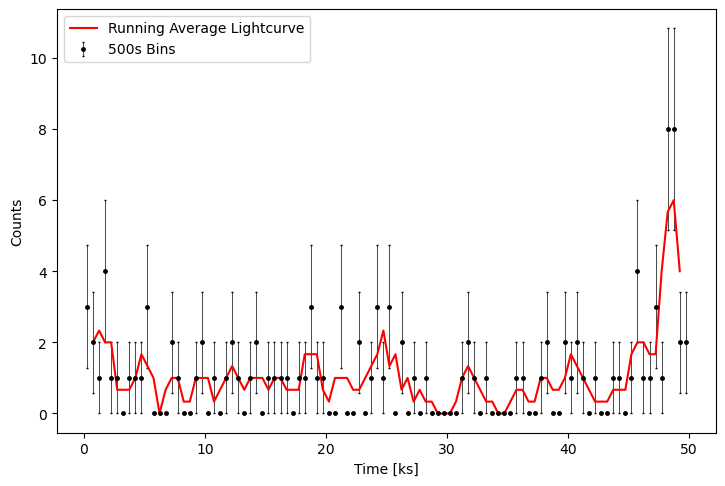

Plotting light curve for 20302_37...
Name: 2CXO J170944.3-443947, RA: 257.4347, DEC: -44.6632, Date: 2018-10-08T12:20:49
var_index_b: 9.0, hard_hs: 0.56964397251718


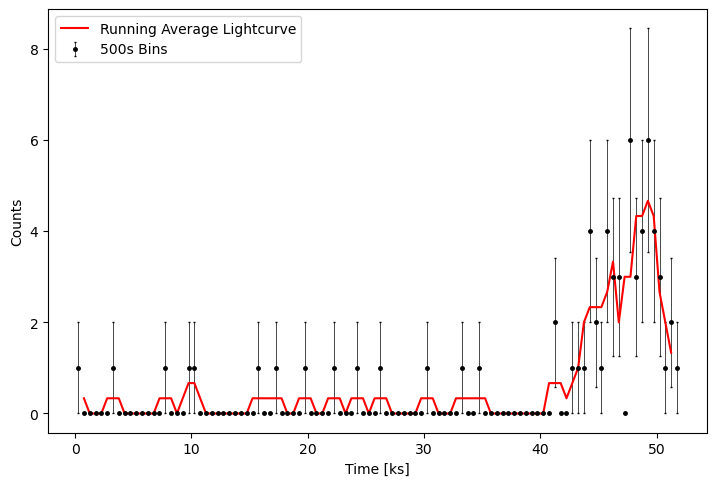

Plotting light curve for 20950_13...
Name: 2CXO J063258.5+054635, RA: 98.2438, DEC: 5.7767, Date: 2018-02-04T12:19:58
var_index_b: 9.0, hard_hs: 0.20861961274204


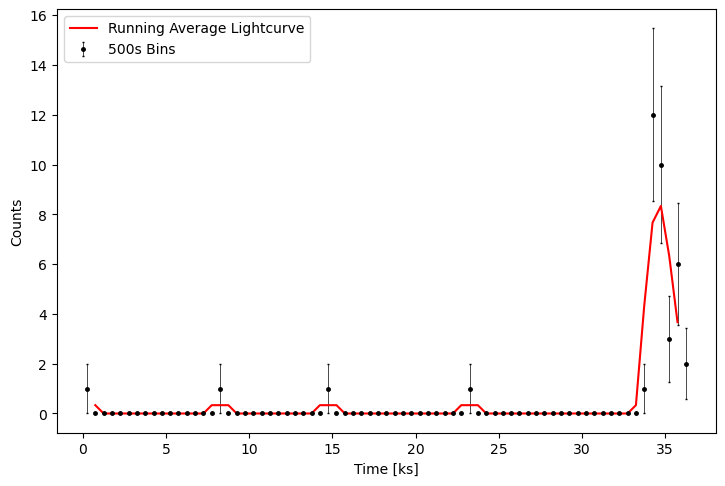

Plotting light curve for 21855_300...
Name: 2CXO J053502.0-051537, RA: 83.7587, DEC: -5.2604, Date: 2018-12-11T23:29:31
var_index_b: 9.0, hard_hs: -0.4422236102436


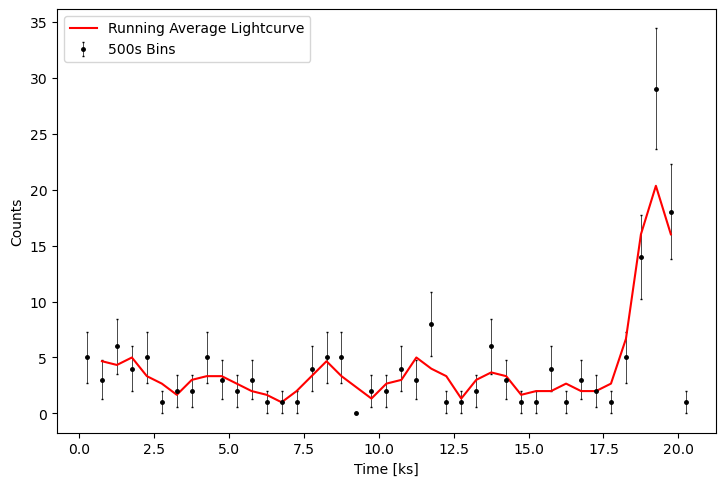

Plotting light curve for 22171_48...
Name: 2CXO J203052.3+440612, RA: 307.7182, DEC: 44.1036, Date: 2019-04-12T00:43:00
var_index_b: 8.0, hard_hs: -0.57713928794503


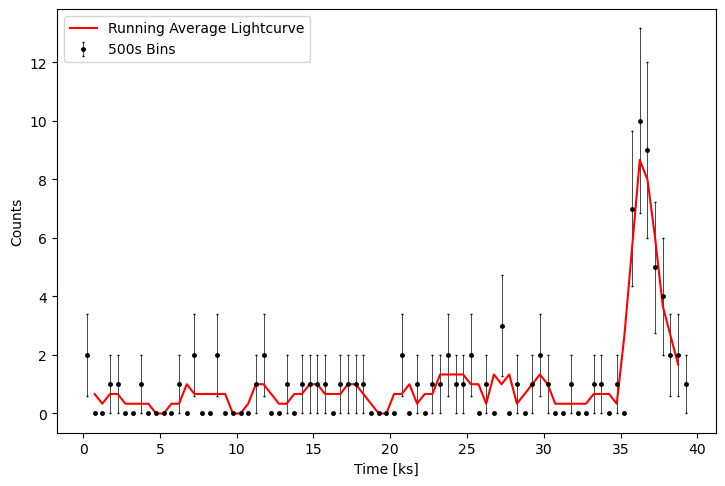

Plotting light curve for 2227_279...
Name: 2CXO J091045.7+542021, RA: 137.6905, DEC: 54.3393, Date: 2001-04-29T05:07:37
var_index_b: 10.0, hard_hs: -0.51967520299813


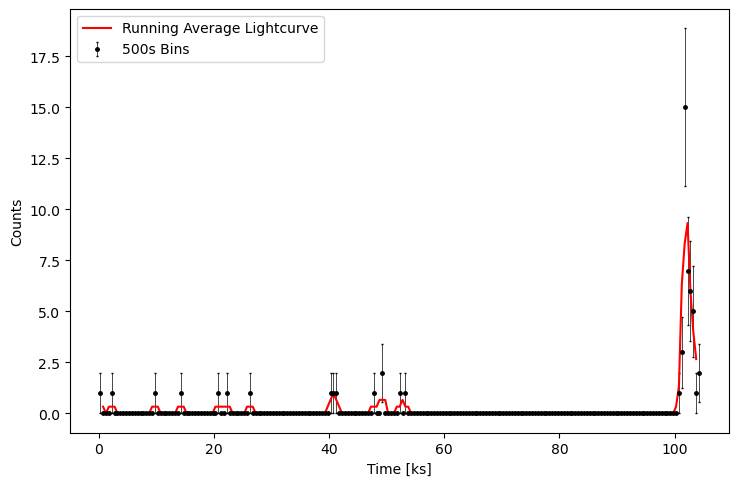

Plotting light curve for 22891_267...
Name: 2CXO J113652.9-613354, RA: 174.2206, DEC: -61.5651, Date: 2019-11-16T08:00:31
var_index_b: 8.0, hard_hs: -0.82073703935041


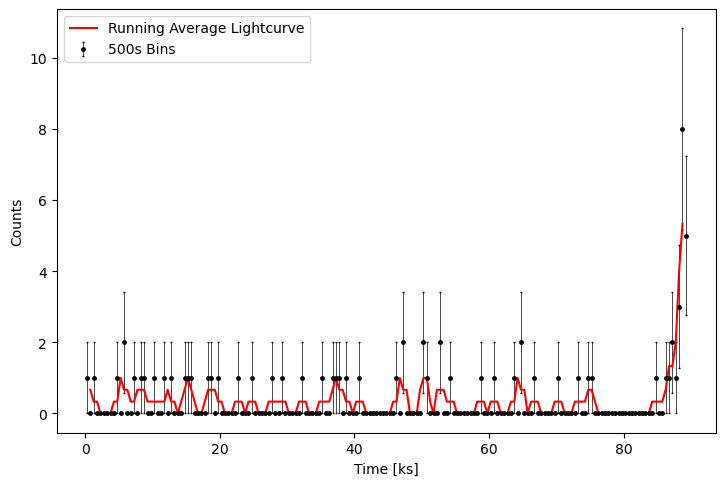

Plotting light curve for 3502_48...
Name: 2CXO J225706.7+623831, RA: 344.2784, DEC: 62.6420, Date: 2003-03-11T12:37:10
var_index_b: 9.0, hard_hs: 0.31480324797002


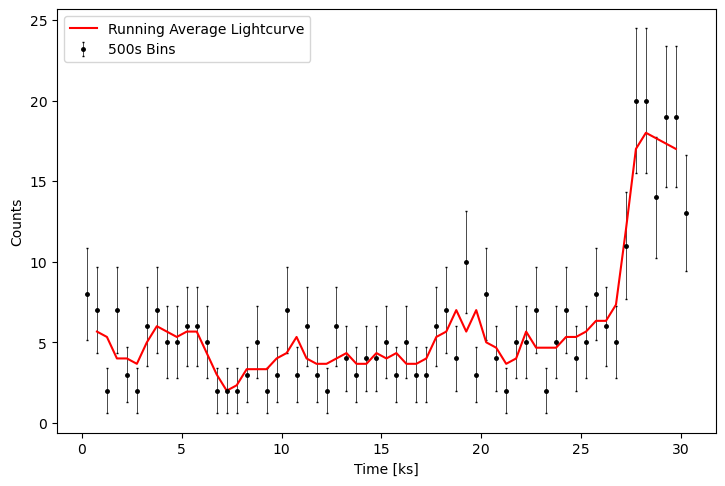

Plotting light curve for 3744_704...
Name: 2CXO J053524.1-052132, RA: 83.8504, DEC: -5.3591, Date: 2003-01-10T16:33:58
var_index_b: 7.0, hard_hs: -0.40599625234229


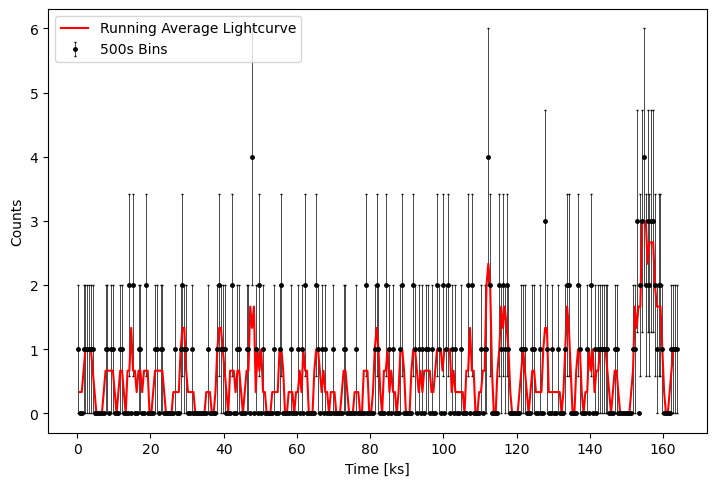

Plotting light curve for 3750_563...
Name: 2CXO J063234.8+050830, RA: 98.1452, DEC: 5.1418, Date: 2004-01-01T02:51:31
var_index_b: 0.0, hard_hs: -0.99937539038101


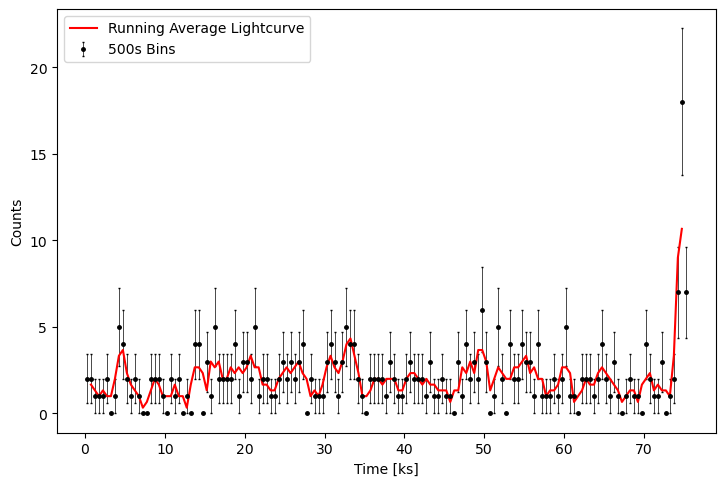

Plotting light curve for 3754_293...
Name: 2CXO J180400.2-242159, RA: 271.0011, DEC: -24.3665, Date: 2003-07-25T17:51:20
var_index_b: 9.0, hard_hs: -0.30730793254216


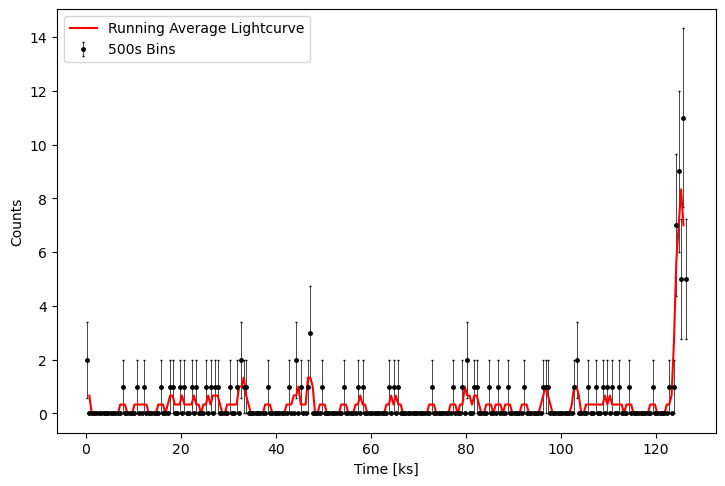

Plotting light curve for 3754_356...
Name: 2CXO J180351.8-242112, RA: 270.9658, DEC: -24.3536, Date: 2003-07-25T17:51:20
var_index_b: 9.0, hard_hs: -0.23860087445347


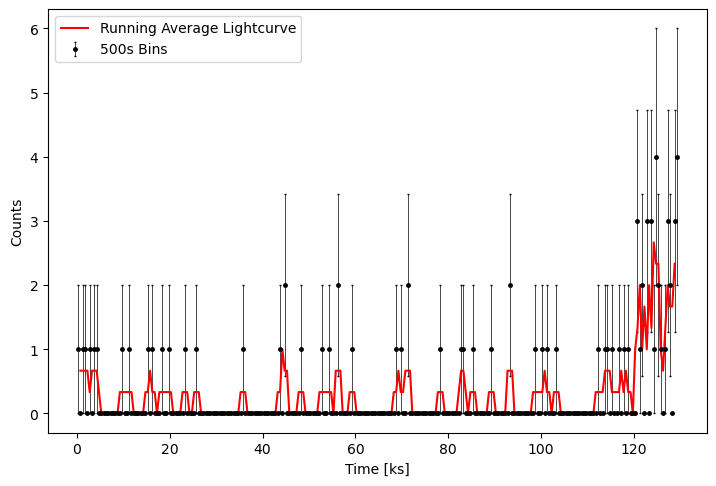

Plotting light curve for 3763_163...
Name: 2CXO J201200.8+382633, RA: 303.0035, DEC: 38.4426, Date: 2003-02-19T18:24:15
var_index_b: 9.0, hard_hs: -0.7632729544035


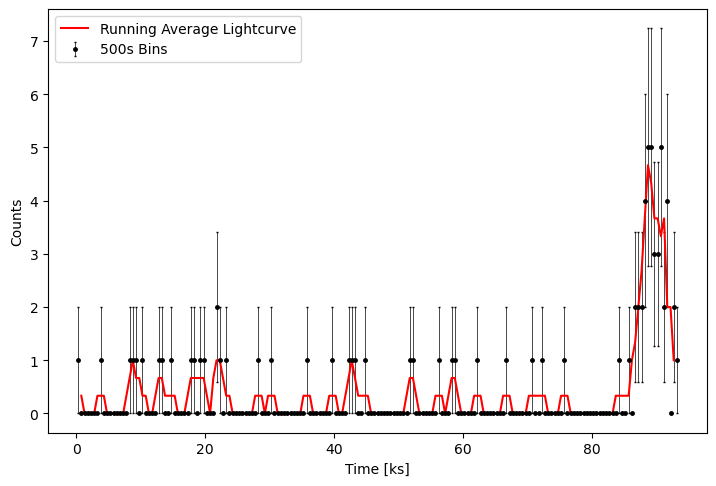

Plotting light curve for 4175_10...
Name: 2CXO J033921.6-354849, RA: 54.8402, DEC: -35.8138, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.0087445346658339


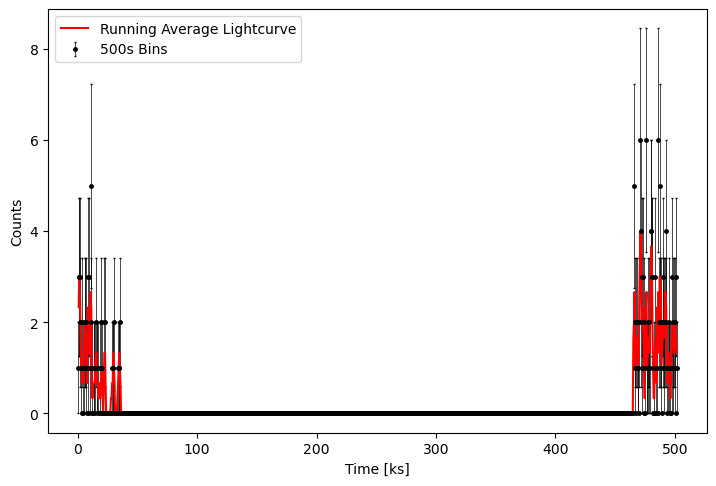

Plotting light curve for 4175_11...
Name: 2CXO J033930.6-354847, RA: 54.8776, DEC: -35.8131, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.4684572142411


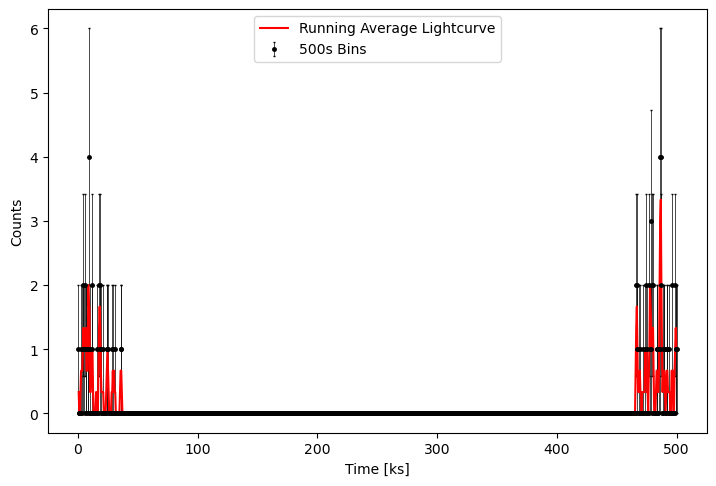

Plotting light curve for 4175_24...
Name: 2CXO J033926.5-354606, RA: 54.8605, DEC: -35.7686, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.043722673329169


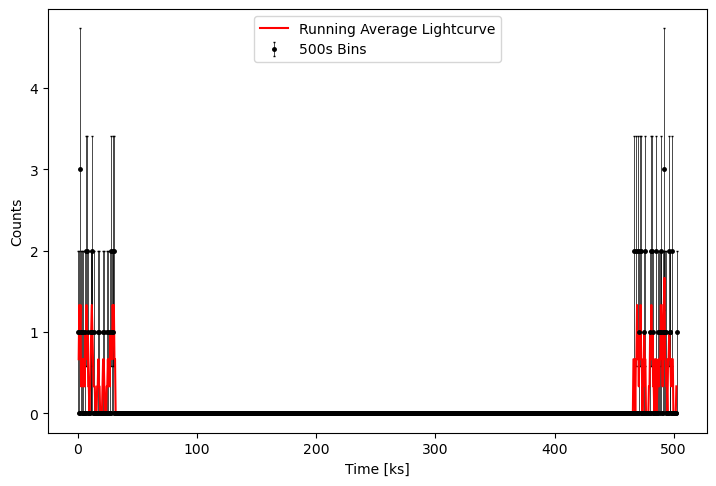

Plotting light curve for 4175_3...
Name: 2CXO J033923.9-355042, RA: 54.8496, DEC: -35.8451, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.29356652092442


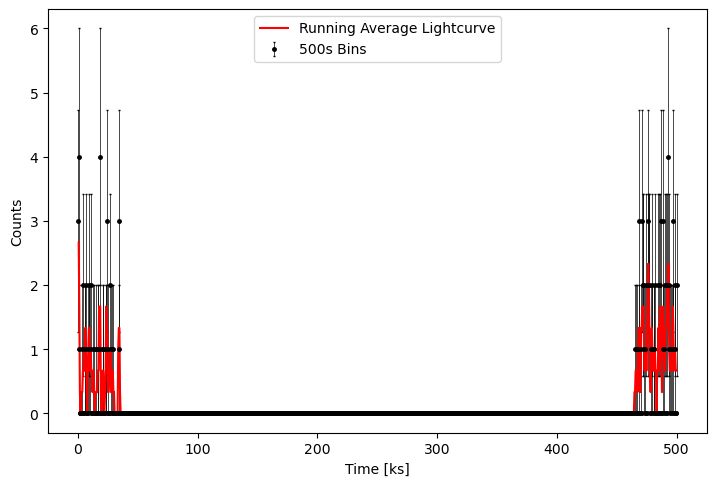

Plotting light curve for 4175_38...
Name: 2CXO J033929.6-354014, RA: 54.8737, DEC: -35.6708, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.19612742036227


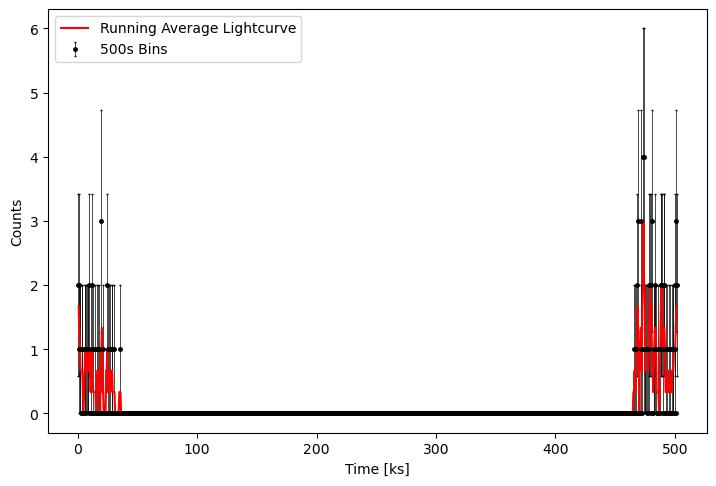

Plotting light curve for 4175_97...
Name: 2CXO J033932.5-354546, RA: 54.8855, DEC: -35.7629, Date: 2003-05-29T11:41:01
var_index_b: 0.0, hard_hs: -0.99937539038101


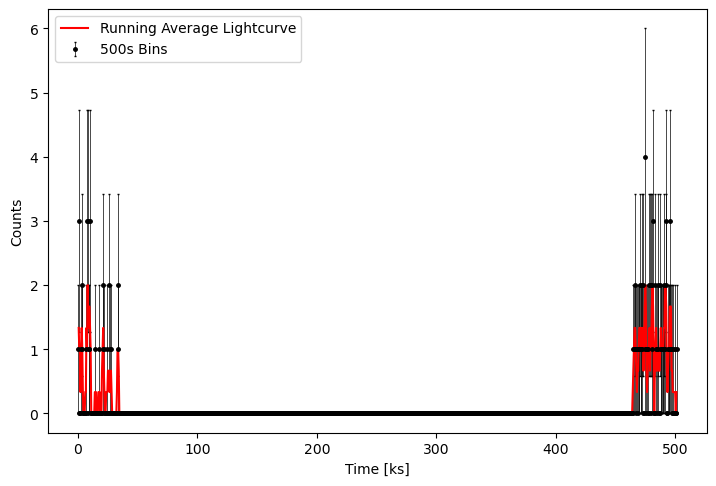

Plotting light curve for 4373_2529...
Name: 2CXO J053510.1-052232, RA: 83.7923, DEC: -5.3757, Date: 2003-01-13T07:51:03
var_index_b: 9.0, hard_hs: 0.99937539038101


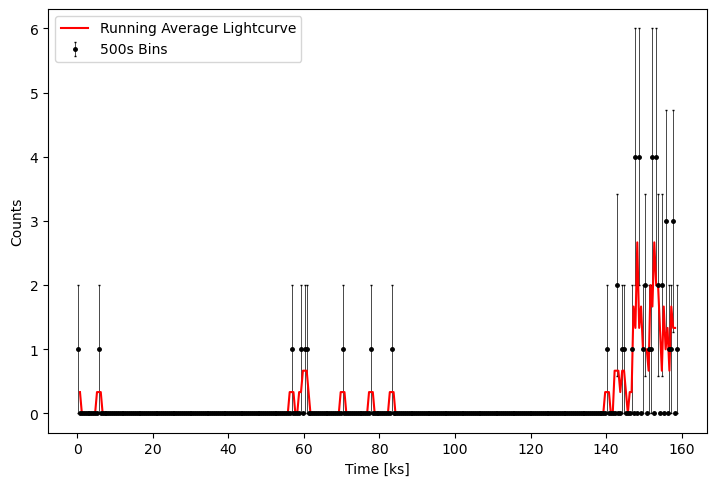

Plotting light curve for 4374_2559...
Name: 2CXO J053514.3-052308, RA: 83.8096, DEC: -5.3856, Date: 2003-01-16T00:16:53
var_index_b: 9.0, hard_hs: 0.60961898813242


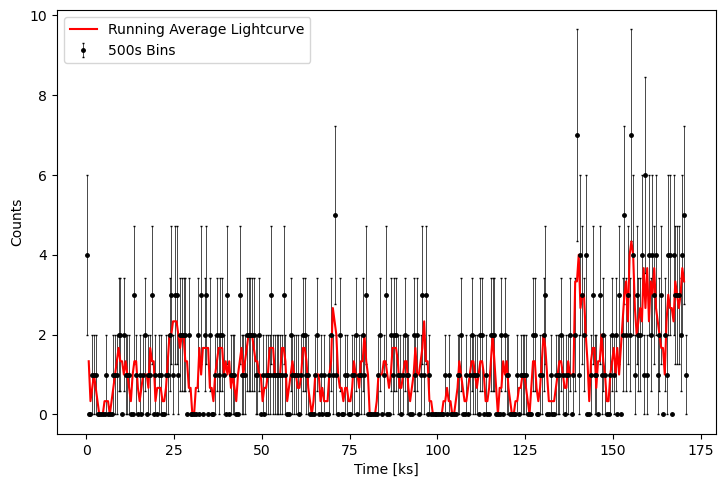

Plotting light curve for 4395_797...
Name: 2CXO J053518.5-052042, RA: 83.8272, DEC: -5.3452, Date: 2003-01-08T21:15:16
var_index_b: 8.0, hard_hs: -0.1524047470331


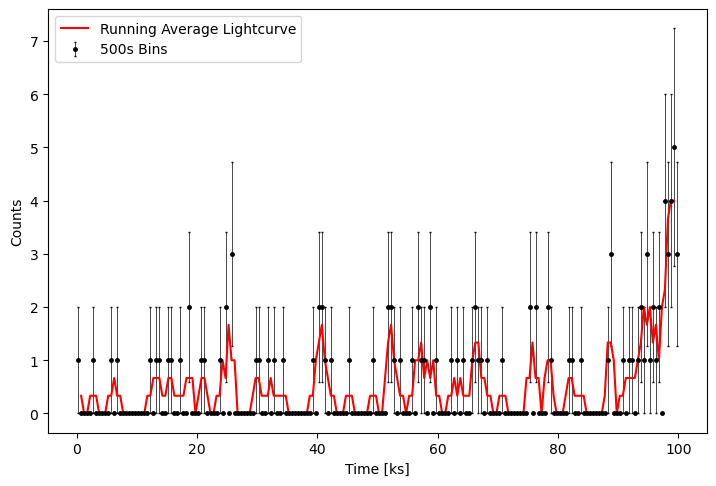

Plotting light curve for 4396_1005...
Name: 2CXO J053511.2-051720, RA: 83.7967, DEC: -5.2891, Date: 2003-01-18T14:51:01
var_index_b: 9.0, hard_hs: 0.016239850093691


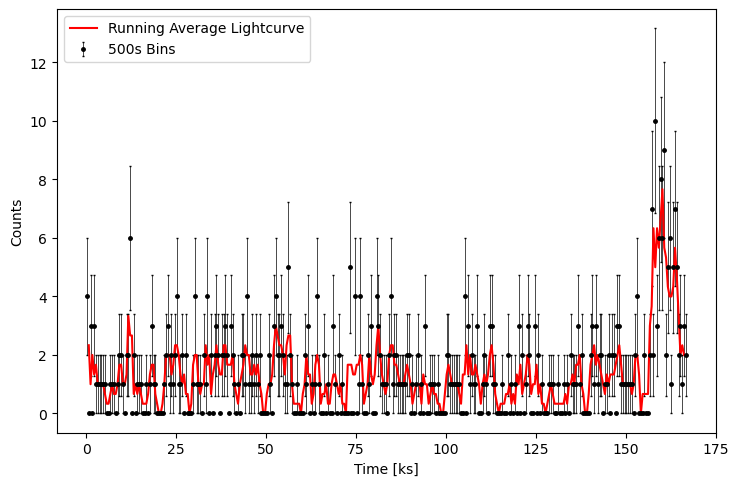

Plotting light curve for 4396_634...
Name: 2CXO J053521.8-052208, RA: 83.8411, DEC: -5.3690, Date: 2003-01-18T14:51:01
var_index_b: 7.0, hard_hs: -0.34353529044347


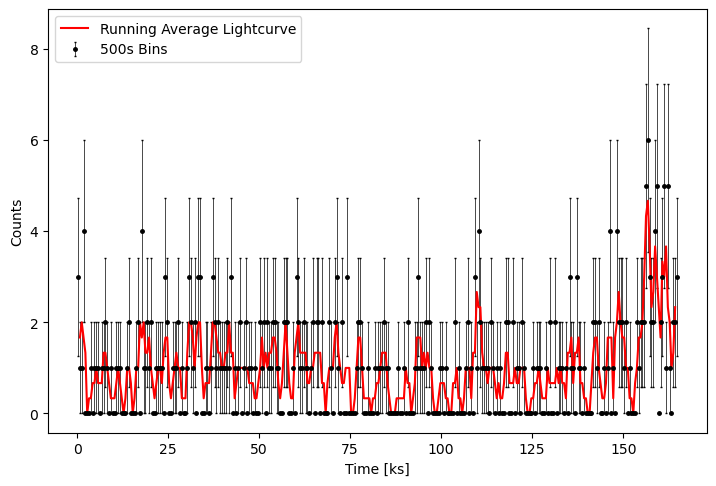

Plotting light curve for 4469_140...
Name: 2CXO J071821.7-245728, RA: 109.5906, DEC: -24.9578, Date: 2003-12-23T03:19:19
var_index_b: 9.0, hard_hs: -0.54465958775765


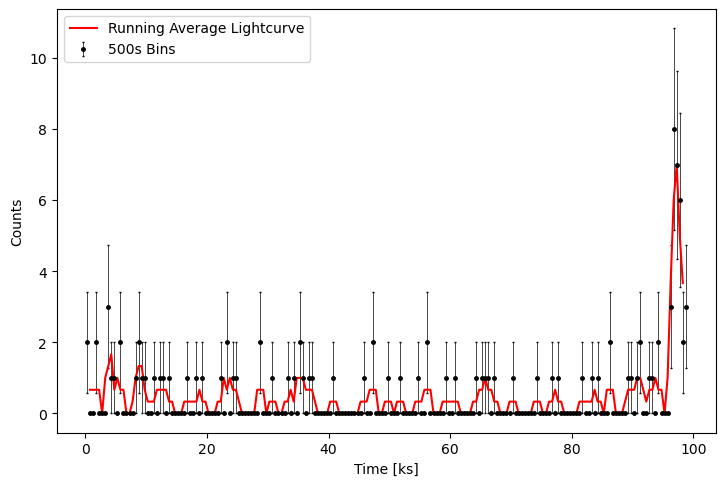

Plotting light curve for 4495_199...
Name: 2CXO J104405.7-593429, RA: 161.0241, DEC: -59.5750, Date: 2004-09-21T17:53:33
var_index_b: 9.0, hard_hs: -0.092442223610244


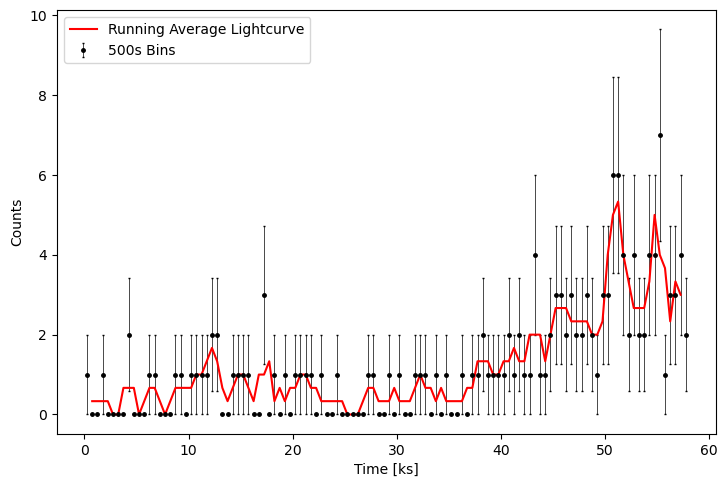

Plotting light curve for 4495_308...
Name: 2CXO J104402.9-593354, RA: 161.0125, DEC: -59.5652, Date: 2004-09-21T17:53:33
var_index_b: 7.0, hard_hs: -0.24484697064335


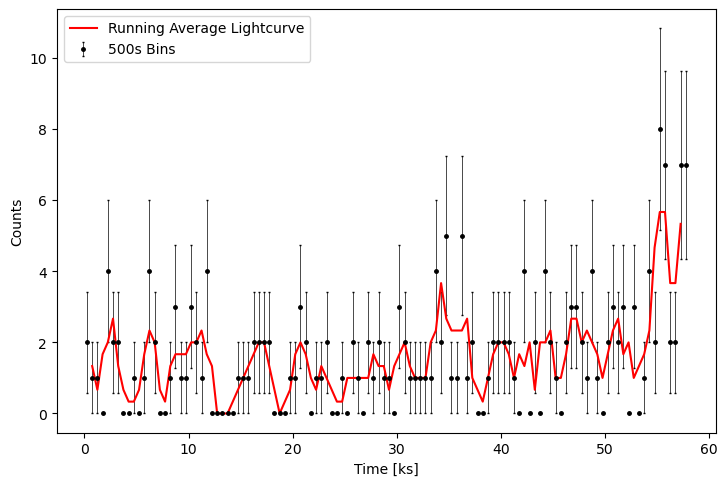

Plotting light curve for 5372_1133...
Name: 2CXO J165423.6-414251, RA: 253.5984, DEC: -41.7143, Date: 2005-07-03T06:33:29
var_index_b: 6.0, hard_hs: -0.28607120549656


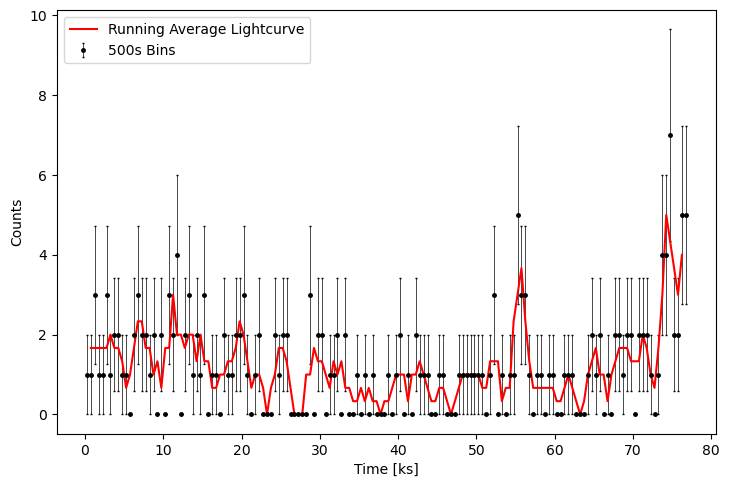

Plotting light curve for 5372_125...
Name: 2CXO J165436.1-415344, RA: 253.6505, DEC: -41.8956, Date: 2005-07-03T06:33:29
var_index_b: 0.0, hard_hs: -0.50843222985634


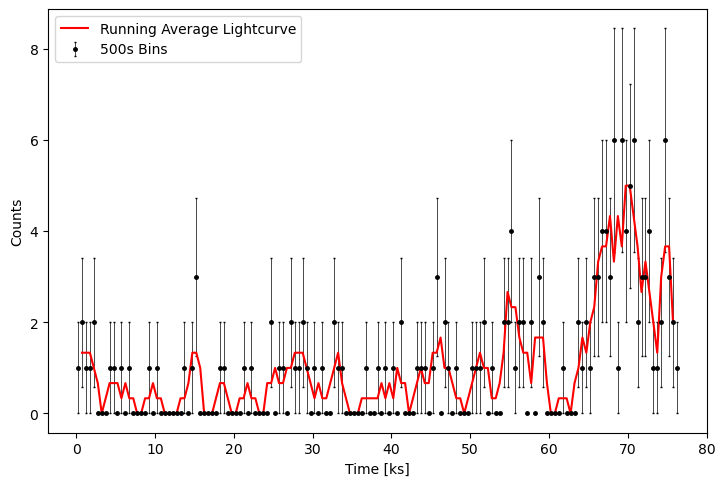

Plotting light curve for 5372_140...
Name: 2CXO J165416.0-415333, RA: 253.5667, DEC: -41.8925, Date: 2005-07-03T06:33:29
var_index_b: 9.0, hard_hs: 0.13491567770144


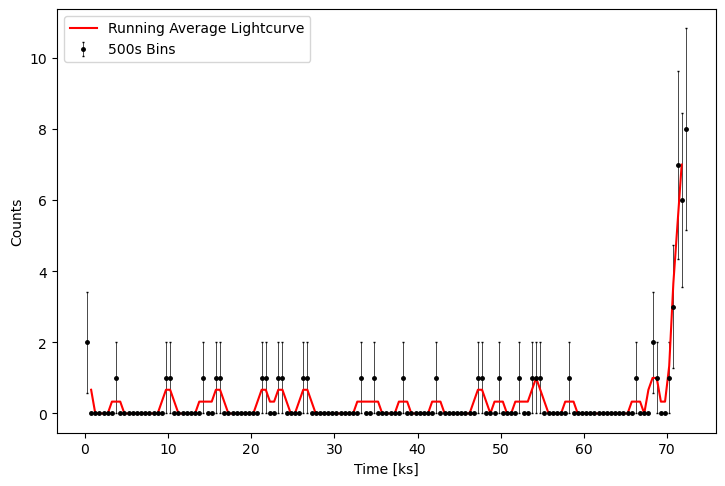

Plotting light curve for 5372_826...
Name: 2CXO J165353.2-414808, RA: 253.4717, DEC: -41.8023, Date: 2005-07-03T06:33:29
var_index_b: 8.0, hard_hs: -0.18113678950656


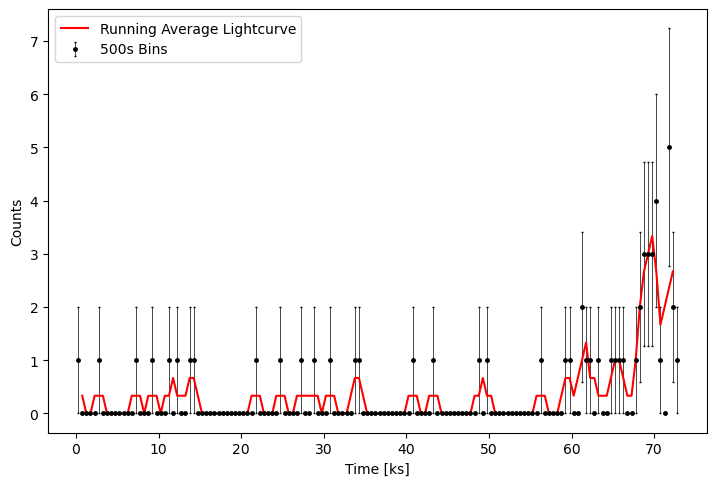

Plotting light curve for 5845_139...
Name: 2CXO J141920.5+530028, RA: 214.8357, DEC: 53.0080, Date: 2005-03-24T14:48:11
var_index_b: 8.0, hard_hs: -0.53091817613991


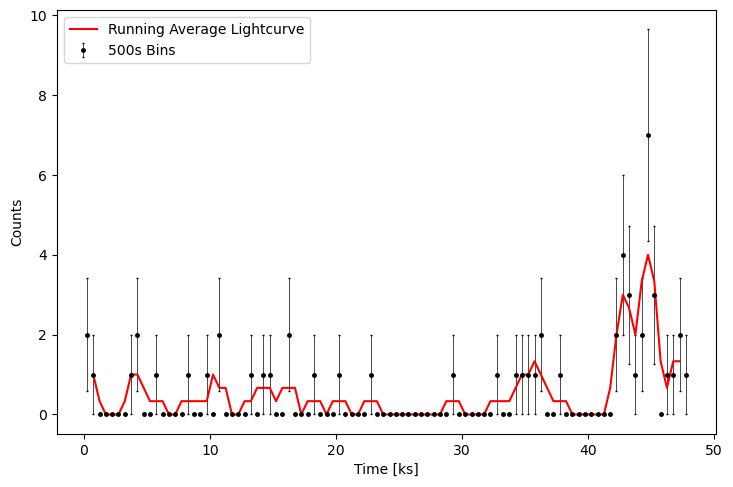

Plotting light curve for 6171_13...
Name: 2CXO J220343.2-564732, RA: 330.9302, DEC: -56.7925, Date: 2004-12-07T14:15:33
var_index_b: 7.0, hard_hs: -0.90943160524672


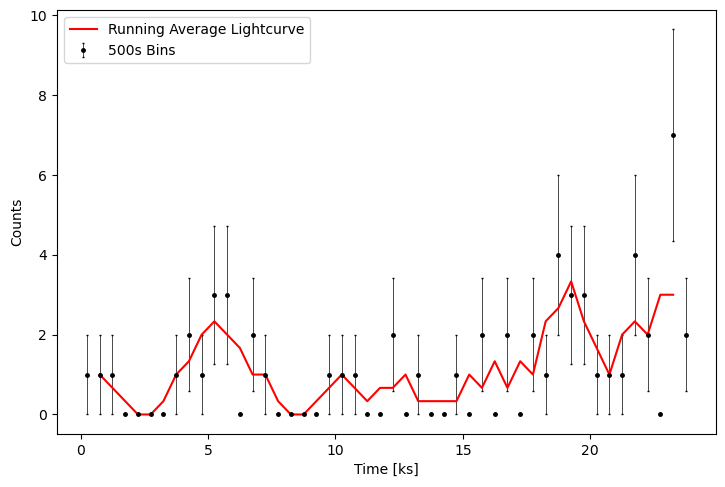

Plotting light curve for 6402_642...
Name: 2CXO J104446.3-593604, RA: 161.1933, DEC: -59.6010, Date: 2006-08-30T19:02:43
var_index_b: 9.0, hard_hs: 0.00999375390381


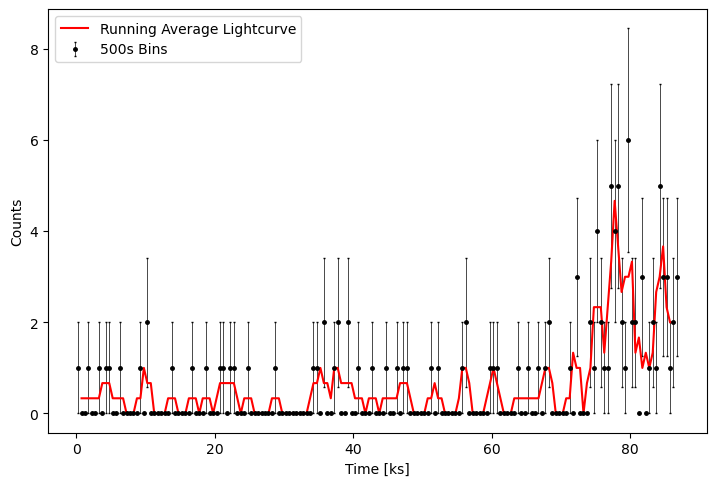

Plotting light curve for 6406_489...
Name: 2CXO J052304.2+332858, RA: 80.7676, DEC: 33.4829, Date: 2006-11-09T13:15:45
var_index_b: 9.0, hard_hs: 0.058713304184884


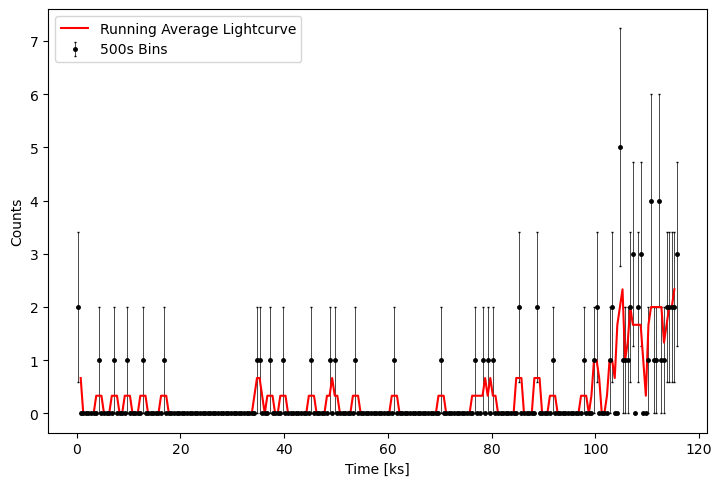

Plotting light curve for 6413_47...
Name: 2CXO J054607.9-000152, RA: 86.5333, DEC: -0.0313, Date: 2005-12-14T16:04:51
var_index_b: 9.0, hard_hs: 0.018738288569644


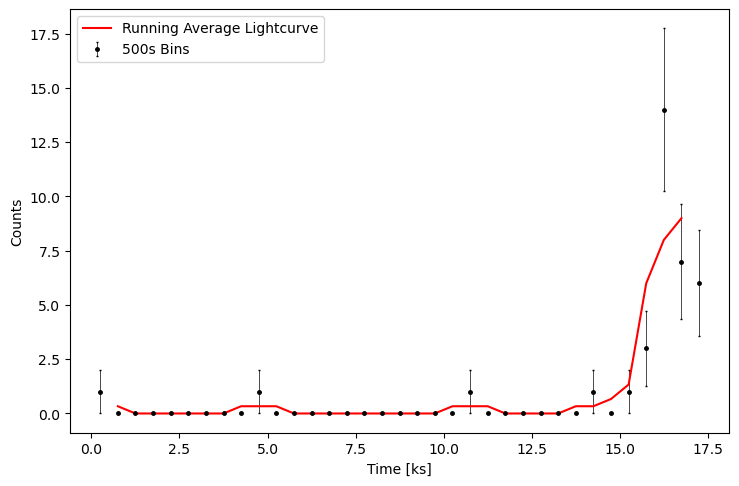

Plotting light curve for 6414_161...
Name: 2CXO J054711.8-000650, RA: 86.7993, DEC: -0.1140, Date: 2006-05-01T04:11:04
var_index_b: 8.0, hard_hs: -0.85321673953779


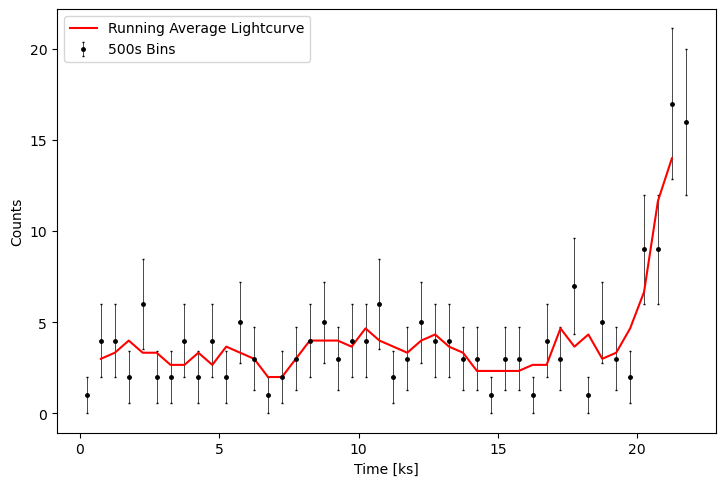

Plotting light curve for 6420_379...
Name: 2CXO J182034.8-161053, RA: 275.1450, DEC: -16.1816, Date: 2006-08-01T02:33:18
var_index_b: 9.0, hard_hs: 0.33978763272954


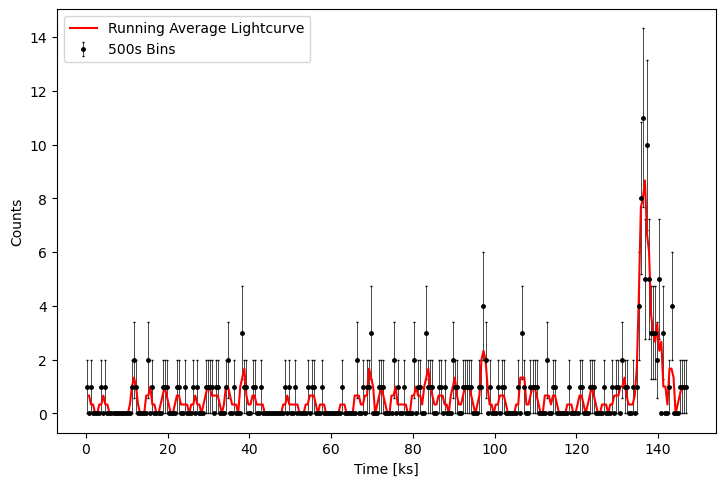

Plotting light curve for 6420_690...
Name: 2CXO J182031.9-160925, RA: 275.1332, DEC: -16.1570, Date: 2006-08-01T02:33:18
var_index_b: 9.0, hard_hs: 0.75327920049969


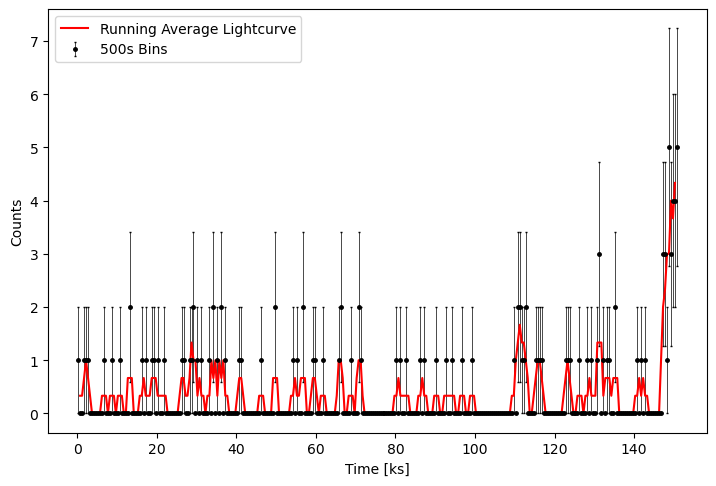

Plotting light curve for 6436_62...
Name: 2CXO J032907.9+312251, RA: 52.2832, DEC: 31.3809, Date: 2006-07-05T15:23:00
var_index_b: 8.0, hard_hs: 0.77826358525921


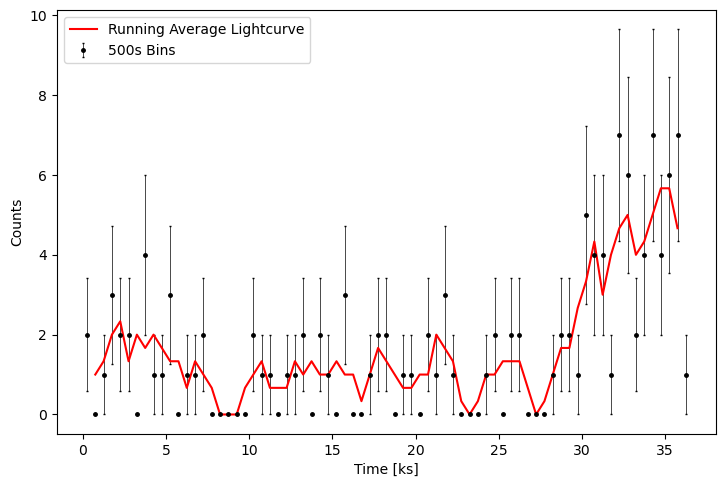

Plotting light curve for 6437_35...
Name: 2CXO J032857.6+311947, RA: 52.2404, DEC: 31.3300, Date: 2006-07-11T10:43:24
var_index_b: 9.0, hard_hs: -0.0737039350406


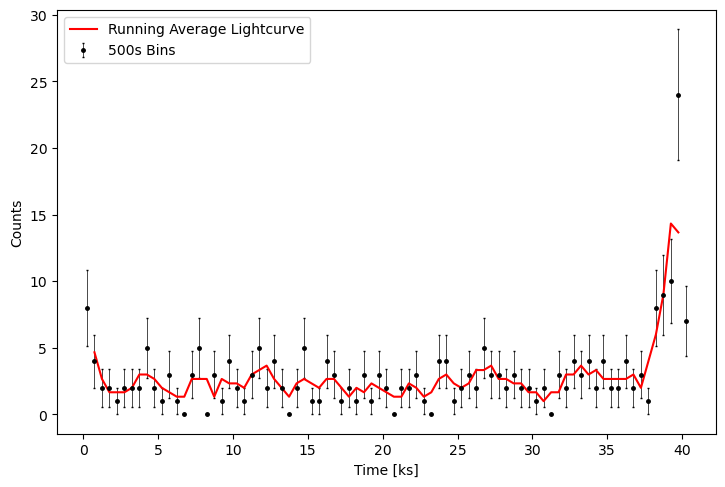

Plotting light curve for 7033_193...
Name: 2CXO J023221.4+613300, RA: 38.0892, DEC: 61.5502, Date: 2006-11-25T23:29:30
var_index_b: 8.0, hard_hs: 0.23360399750156


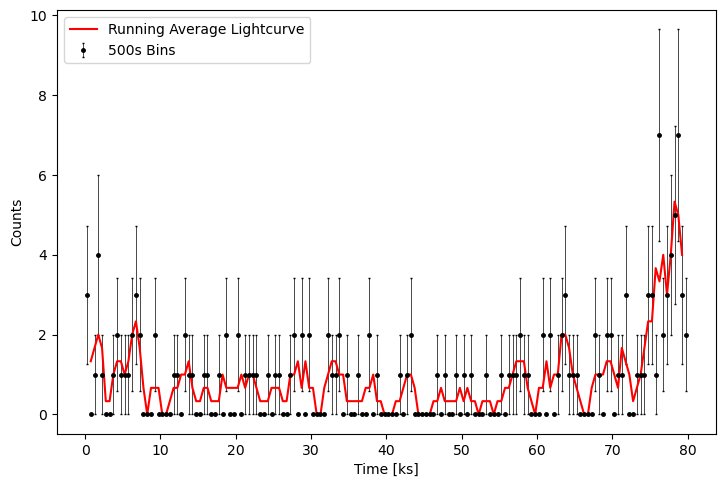

Plotting light curve for 8458_40...
Name: 2CXO J002033.2+592135, RA: 5.1386, DEC: 59.3597, Date: 2006-11-04T23:50:47
var_index_b: 9.0, hard_hs: -0.2948157401624


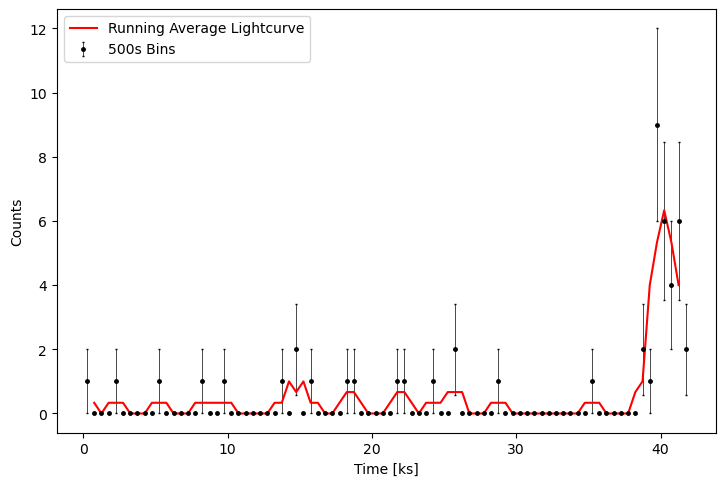

Plotting light curve for 8461_2326...
Name: 2CXO J182033.2-161843, RA: 275.1387, DEC: -16.3121, Date: 2006-11-11T00:40:30
var_index_b: 9.0, hard_hs: -0.1736414740787


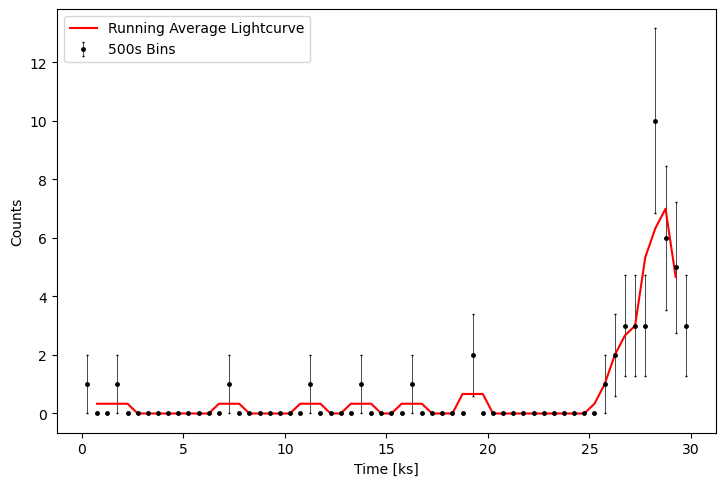

Plotting light curve for 9138_819...
Name: 2CXO J151344.2-590214, RA: 228.4344, DEC: -59.0372, Date: 2008-06-19T19:08:33
var_index_b: 0.0, hard_hs: -0.9156777014366


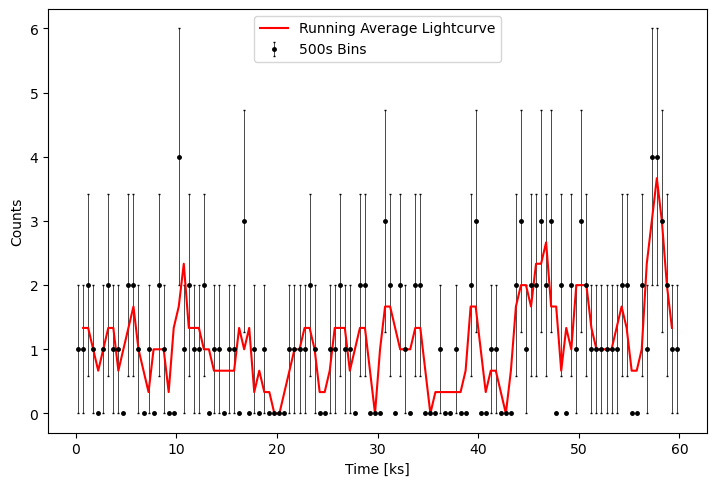

Plotting light curve for 9408_162...
Name: 2CXO J074414.9+375645, RA: 116.0620, DEC: 37.9460, Date: 2007-12-11T13:12:55
var_index_b: 8.0, hard_hs: -0.8632104934416


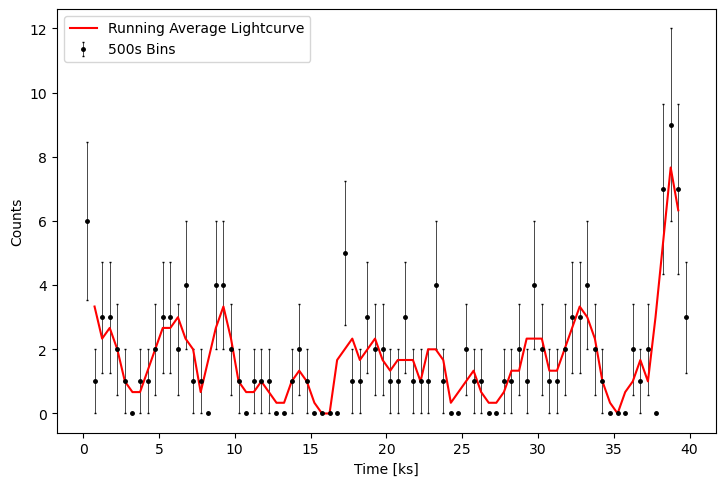

Plotting light curve for 943_136...
Name: 2CXO J025646.3+192838, RA: 44.1929, DEC: 19.4772, Date: 2000-08-17T01:06:05
var_index_b: 0.0, hard_hs: 0.82948157401624


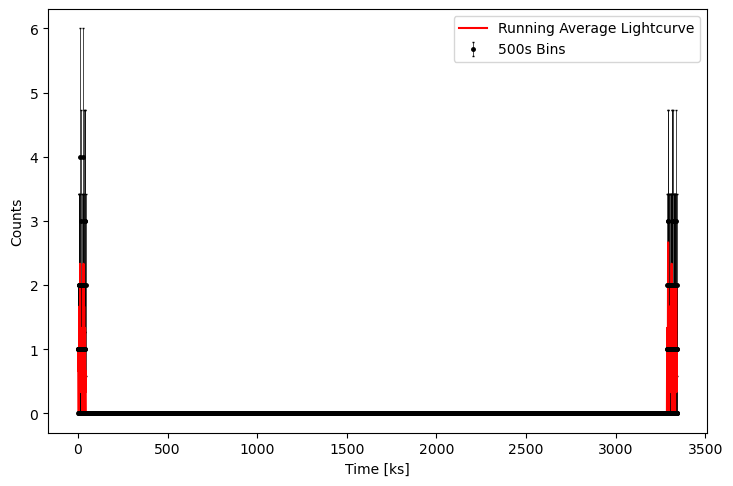

Plotting light curve for 943_29...
Name: 2CXO J025544.5+193633, RA: 43.9358, DEC: 19.6093, Date: 2000-08-17T01:06:05
var_index_b: 0.0, hard_hs: 0.3997501561524


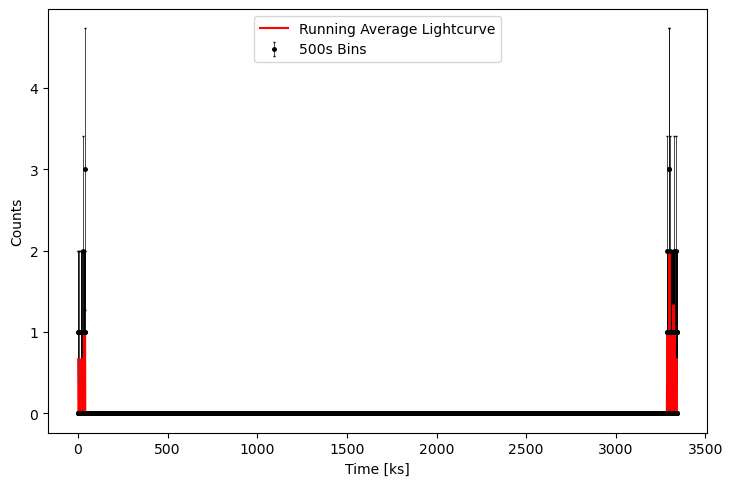

Plotting light curve for 9490_38...
Name: 2CXO J104748.7-595839, RA: 161.9533, DEC: -59.9775, Date: 2008-09-09T19:45:10
var_index_b: 9.0, hard_hs: -0.49094316052467


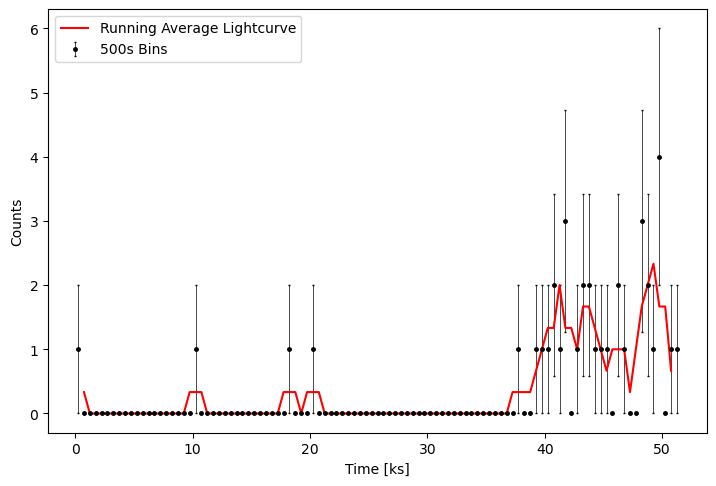

Plotting light curve for 949_81...
Name: 2CXO J184422.5-040350, RA: 281.0940, DEC: -4.0641, Date: 2000-02-25T22:22:16
var_index_b: 9.0, hard_hs: -0.26733291692692


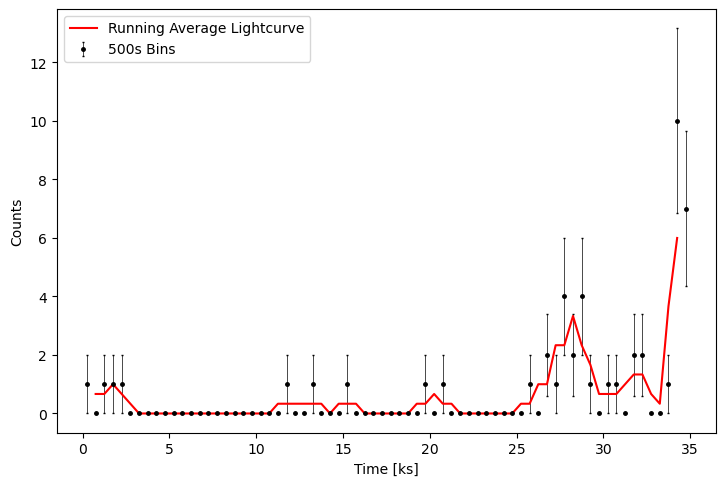

Plotting light curve for 9548_14...
Name: 2CXO J112017.5+125818, RA: 170.0729, DEC: 12.9719, Date: 2008-03-31T14:51:36
var_index_b: 10.0, hard_hs: -0.41474078700812


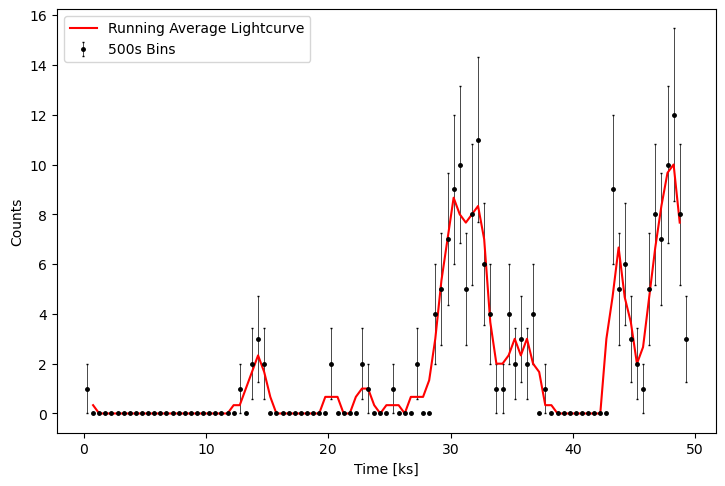

Plotting light curve for 972_866...
Name: 2CXO J182019.7-160820, RA: 275.0823, DEC: -16.1389, Date: 2002-03-02T17:28:27
var_index_b: 9.0, hard_hs: 0.841973766396


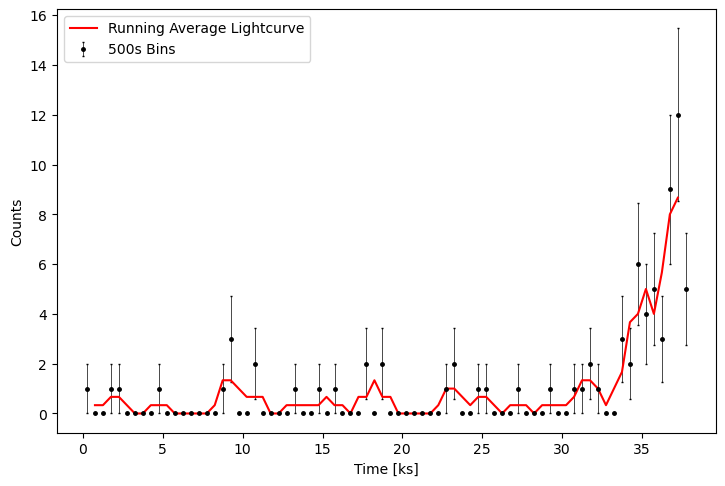

In [28]:
# === Light Curve Visualization ===============================================

# Load the selection
if selection_widget.value != 'Current Notebook Selection':
    df_selection = pd.read_csv('../output/selections/' + selection_widget.value)
else:
    df_selection = selected_df
selected_ids = df_selection['obsreg_id'].values

# Load the eventfiles
df_selected_eventfiles = df_eventfiles[df_eventfiles['obsreg_id'].isin(selected_ids)]
df_eventfiles_grouped = df_selected_eventfiles.groupby('obsreg_id')

# Initialize the light curve plotter
lc_plotter = LightCurve()

# Plot the light curves
for obsreg_id, group in df_eventfiles_grouped:
    print(f'Plotting light curve for {obsreg_id}...')
    #Retrieve metadata
    name = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].name.values[0]
    ra = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].ra.values[0]
    dec = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].dec.values[0]
    date = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].gti_obs.values[0]
    var_index_b = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].var_index_b.values[0]
    hard_hs = df_properties_full[df_properties_full['obsreg_id'] == obsreg_id].hard_hs.values[0]
    print(f'Name: {name}, RA: {ra:.4f}, DEC: {dec:.4f}, Date: {date}')
    print(f'var_index_b: {var_index_b}, hard_hs: {hard_hs}')
    # Get the eventfile
    df_selected = df_eventfiles[df_eventfiles['obsreg_id'] == obsreg_id]
    # Bin the light curve
    binned_lightcurves = lc_plotter.bin(df_selected, bin_size_sec=bin_size_widget.value)
    # Visualize the light curve
    lc_plotter.visualise(color='k', ecolor='k', rcolor='red', lw=1.5, lwe=0.5, capsize=1, markersize=5)
